# Project Data Science
***Auteurs : DIALLO Bintou, RIPOLL Thomas***

***Thématique Business:***

Fidélisation client, anticipation du taux d'attrition (Churn) et évaluation du risque de revenus pour les entreprises de services.

***Contexte métier:***

Le taux de désabonnement (churn) est l'un des défis les plus critiques pour les entreprises fonctionnant par abonnement (SaaS, Télécoms, e-commerce). Fidéliser les clients existants étant nettement plus rentable que d'en acquérir de nouveaux, la prédiction du churn est un enjeu stratégique majeur. Pour une entreprise orientée service, l'objectif est d'assurer une expérience optimale en suivant de près l'utilisation des produits, l'historique de facturation et les interactions avec le support client afin de maximiser la rétention.

***Jeu de données:***

* **Source de données :** Kaggle
* **Nature du dataset :** Données synthétiques générées selon une logique métier réaliste (Customer Churn Business Dataset).
* **Volume :** 10 000 lignes (clients).
* **Variables :** 32 variables au total (Numériques et Catégorielles). Ces variables se divisent en cinq grandes catégories :
    * **Profil Client :** Âge, genre, localisation, segment, ancienneté, type de contrat.
    * **Utilisation du produit :** Fréquence de connexion, durée des sessions, fonctionnalités utilisées, évolution de l'usage.
    * **Facturation et Paiement :** Forfait mensuel, revenu total, échecs de paiement, réductions appliquées.
    * **Support Client :** Nombre de tickets, temps de résolution, type de réclamation, score CSAT.
    * **Engagement et Retours :** Taux d'ouverture des emails, clics marketing, score NPS, réponses aux enquêtes.
* **Variable cible :** `churn` (0 = Non, 1 = Oui).

***Problématique business:***

Nous intervenons en tant que Data Scientists pour concevoir un système intelligent d'aide à la décision. Notre entreprise souhaite identifier en amont les clients présentant un risque élevé de résiliation. Prédire ces départs permettra aux équipes marketing et CRM de prioriser les actions de rétention (offres ciblées, support proactif, ajustements tarifaires), de réduire le coût d'acquisition et de sécuriser le chiffre d'affaires (revenu à risque).

***Objectifs Data Science:***

1. **Analyse Exploratoire (EDA) :** Identifier les facteurs clés (drivers) qui influencent le plus le départ d'un client (ex: échecs de paiement, temps de résolution du support, baisse de l'engagement).
2. **Modélisation Multi-Algorithmes :** Développer, entraîner et comparer plusieurs modèles de Machine Learning et de Deep Learning (Classification binaire) capables de prédire la probabilité de désabonnement.
3. **Explicabilité (Explainable AI) :** Interpréter les décisions du modèle (Feature importance) pour comprendre *pourquoi* un client est classé à risque.

##  Analyse exploratoire des données (EDA)
À réaliser dans un notebook Jupyter (.ipynb) avec analyse de la structure, statistiques
descriptives, valeurs manquantes, visualisations, corrélations, outliers et hypothèses.

### EDA-1 : Analyse de la structure du dataset
Vérification de la taille des données, du nom des colonnes et du type de variables:

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

#1) Chargement du fichier de données
df = pd.read_csv('data/customer_churn_business_dataset.csv')

#2) Analyse de la structure (Taille et types de données)
print("Taille du dataset :", df.shape)
print("-" * 40)
df.info()

#3) Affichage des 5 premières lignes pour un aperçu
display(df.head())

print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")


Taille du dataset : (10000, 32)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate  

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


Le dataset contient 10000 lignes et 32 colonnes.


**Interprétation :** Nous commençons par cette étape afin d'avoir un aperçu global de notre dataset, de la structure des données qu'il contient, ainsi que du profil client.

* **Volume et pertinence :** Le dataset contient 10 000 lignes et 32 colonnes. C'est un volume de données plus important et très satisfaisant pour entraîner et comparer nos algorithmes.

* **Nature des données :** Le profil client est ici très détaillé. On observe une grande richesse dans les types de variables : 16 variables numériques continues ou discrètes (comme `monthly_logins`, `csat_score` ou `tenure_months`) et 12 variables catégorielles/textuelles (comme `customer_segment`, `payment_method` ou `contract_type`). 

* **Qualité des données (Valeurs manquantes) :** Le résultat de la colonne "Non-Null Count" nous confirme que notre dataset est parfaitement rempli pour 31 de ses 32 colonnes. Cependant, on remarque une exception majeure : la colonne `complaint_type` ne contient que 7 955 valeurs non nulles. Cela signifie qu'il manque environ 20 % des données sur cette variable, ce qu'il faudra impérativement traiter lors de l'étape de nettoyage (cela correspond probablement aux clients n'ayant jamais fait de réclamation).

#EDA-2 : Statistiques descriptives

Analyse des moyennes, valeurs minimales et maximales pour comprendre la distribution de nos clients.

In [92]:
#stats des colonnes avec des nombres (moyenne, min, max, etc.)
display(df.describe())

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


**Interprétation :**

## Variables numériques :

- On remarque que l'ancienneté (`tenure_months`) moyenne de nos clients est d'environ 30 mois, avec quelques écarts : le minimum étant de 1 mois (clients tout nouveaux) et le maximum atteignant 59 mois.
- Pour ce qui est du prix payé, la facture mensuelle (`monthly_fee`) varie de 10 à 100, avec une moyenne autour de 34,93.
- Étant donné que le `churn` est représenté de manière binaire (valeurs 0 ou 1) dans ce tableau de bord, sa moyenne à environ 0.102 nous fait comprendre que le taux de désabonnement global est d'environ 10,2 %. 
- Nous pouvons également noter que l'âge moyen de notre clientèle est d'environ 46 ans, allant de 18 à 74 ans.

## Variables catégorielles :    

- Pour notre colonne la plus importante (`churn`), nous pouvons confirmer que la valeur la plus fréquente est 0, ce qui signifie que la plupart des clients restent. Cela nous indique que nous avons un jeu de données déséquilibré (beaucoup plus de "No" que de "Yes"), un point technique important pour la suite.
- Nous avons également de nouvelles variables comme le type de contrat (`contract_type` avec des contrats "Monthly", "Yearly", etc.). C'est trop tôt pour affirmer mathématiquement si un contrat mensuel augmente la volatilité d'un utilisateur, mais cela reste une excellente piste à garder en tête pour nos futures hypothèses lors des visualisations.

### EDA-3. Gestion des valeurs manquantes et recherches des doublons

 - suppression col : customer_id (inutile pour EDA ou le Machine Learning)
 - Colonnes Objets : Objet -> catégotry 

In [93]:

#Supression de la colonne customer_id
df = df.drop('customer_id', axis=1)


#Transformation des types objets en category pour plus de coherence
colonnes_textes = df.select_dtypes(include=['object']).columns.to_list()
print(colonnes_textes)
for col in colonnes_textes:
    df[col] = df[col].astype('category')

# nb de valeurs manquantes dans chaque colonne
print(df.isnull().sum())

#suppresion valeurs manquantes
df = df.dropna()

# Recherche des doublons
nb_doublons = df.duplicated().sum()
print("Nombre de doublons :", nb_doublons)
df = df.drop_duplicates()

['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']
gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            2045
csat_score                   0
escalations                  0
email_open_rate              0
marketin

**Interprétation du nettoyage inituak des données :**

- **Gestion des valeurs manquantes :** L'analyse a mis en évidence l'absence de valeurs nulles dans la quasi-totalité du dataset, à l'exception notable de la colonne `complaint_type` (2045 valeurs manquantes). Au lieu de supprimer ces lignes (ce qui aurait entraîné une perte de plus de 20 % de nos données), nous avons comblé ces vides avec la mention "No_complaint", supposant logiquement que ces clients n'ont tout simplement pas émis de réclamation. Le `dropna()` final sécurise le reste du tableau.
- **Suppression des colonnes non prédictives :** Nous avons supprimé la colonne `customer_id`. S'agissant d'un identifiant purement unique, elle n'apporte aucune information utile à un algorithme d'apprentissage automatique pour prédire le départ d'un client.
- **Optimisation de la mémoire :** En transformant les colonnes de type objet en type `category`, nous réduisons considérablement la taille du dataset en mémoire. Cela permet de standardiser les variables et d'améliorer la vitesse d'exécution pour la suite du pipeline.
- **Absence de doublons :** La vérification nous confirme que notre jeu de données est parfaitement sain à ce niveau-là, avec 0 ligne dupliquée.

In [94]:
#Verification des types des colonnes après les transformations

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7955 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   gender                  7955 non-null   category
 1   age                     7955 non-null   int64   
 2   country                 7955 non-null   category
 3   city                    7955 non-null   category
 4   customer_segment        7955 non-null   category
 5   tenure_months           7955 non-null   int64   
 6   signup_channel          7955 non-null   category
 7   contract_type           7955 non-null   category
 8   monthly_logins          7955 non-null   int64   
 9   weekly_active_days      7955 non-null   int64   
 10  avg_session_time        7955 non-null   float64 
 11  features_used           7955 non-null   int64   
 12  usage_growth_rate       7955 non-null   float64 
 13  last_login_days_ago     7955 non-null   int64   
 14  monthly_fee             7955 

Interprétation :    

Maintenant que notre tableau est propre et allégé. Chaque colonne a enfin le bon format : des vrais nombres pour les prix et l'ancienneté, et des catégories pour le texte.

### EDA-4. Recherche des Outliers (=Valeurs aberrantes)
Nous cherchns à repérer si certains clients ont des facturations ou des anciennetés anormales. Afin d'éviter que des variable extrêmes ne faussent nos analyses.

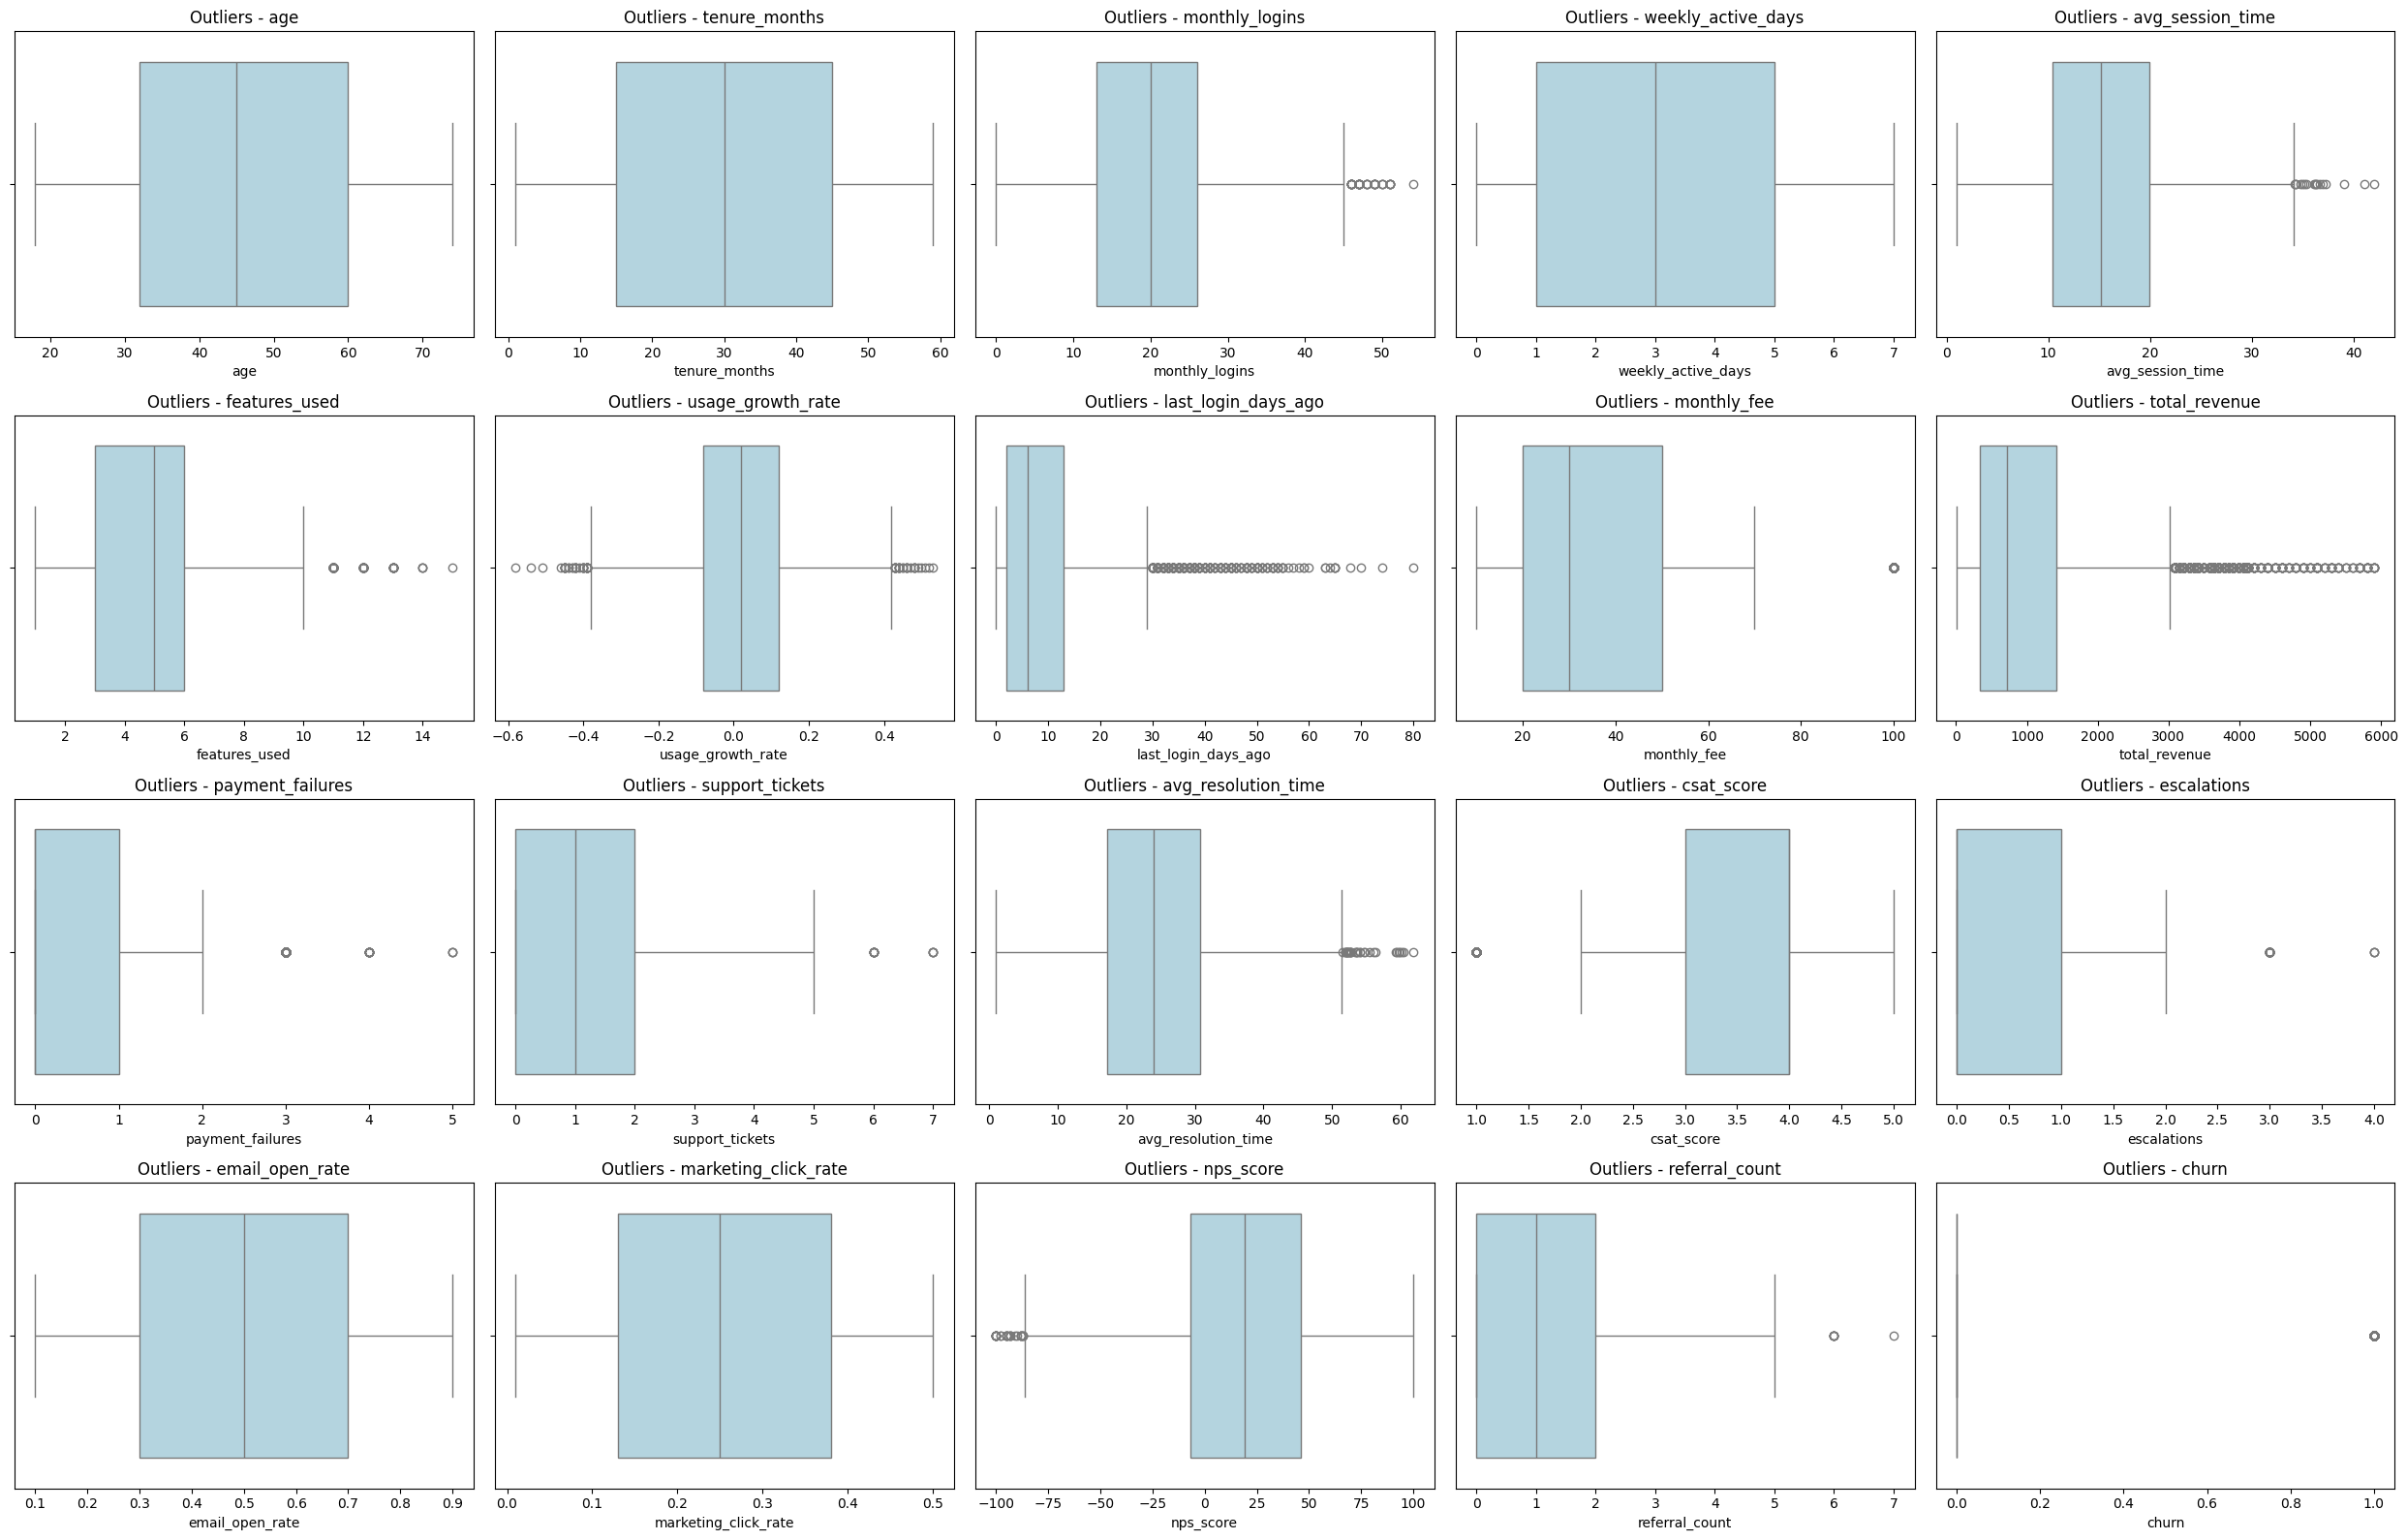

In [95]:
import math

# Sélection automatique des variables numériques
colonnes_num = df.select_dtypes(include=['int64', 'float64']).columns
nb_colonnes = len(colonnes_num)

nb_lignes = math.ceil(nb_colonnes / 5)
plt.figure(figsize=(25, 4 * nb_lignes))

for i, col in enumerate(colonnes_num, 1):
    plt.subplot(nb_lignes, 5, i)
    sns.boxplot(x=df[col], color='lightblue')
    plt.title(f'Outliers - {col}')

plt.tight_layout()
plt.show()

**Interprétation des valeurs aberrantes (Outliers) :**

En observant nos boîtes à moustaches (boxplots), nous constatons visuellement l'absence totale de points au-delà des limites (les "moustaches"). Cela signifie que nos données pour le revenu total, l'âge, et les métriques d'engagement (connexions, jours actifs, fonctionnalités) ne contiennent aucune valeur extrême aberrante. 

**Ce que cela signifie d'un point de vue métier et technique :**

- **Qualité des données garantie :** L'absence d'outliers confirme d'abord qu'il n'y a eu aucune erreur informatique ou faute de frappe lors de l'enregistrement des données dans la base (par exemple : un âge saisi à 150 ans, ou un client facturé 999 999).
- **Cohérence de la facturation :** Les montants du revenu total évoluent dans des limites classiques et prévisibles. La politique tarifaire de l'entreprise est structurée et ne subit pas d'écarts extrêmes invisibles, ce qui nous assure que le risque financier lié au churn pourra être calculé sur des bases saines.
- **Comportement client homogène :** L'utilisation du service (fréquence de connexion et fonctionnalités utilisées) suit une distribution régulière. L'absence d'activité démesurée ou anormale rendra l'apprentissage de nos modèles de Machine Learning beaucoup plus stable.

### EDA-5 Visualisations
Nous souhaitons faire des visualisations pour essayer comprendre ce qui pousse un client au désabonnement

C:\Users\thoma\AppData\Local\Temp\ipykernel_55404\1409457174.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 0], data=df, x='churn', y='support_tickets', palette='Set2')
C:\Users\thoma\AppData\Local\Temp\ipykernel_55404\1409457174.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], data=df, x='churn', y='csat_score', palette='Set2')
C:\Users\thoma\AppData\Local\Temp\ipykernel_55404\1409457174.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 0], data=df, x='churn', y='nps_score', palette='Set2')
C

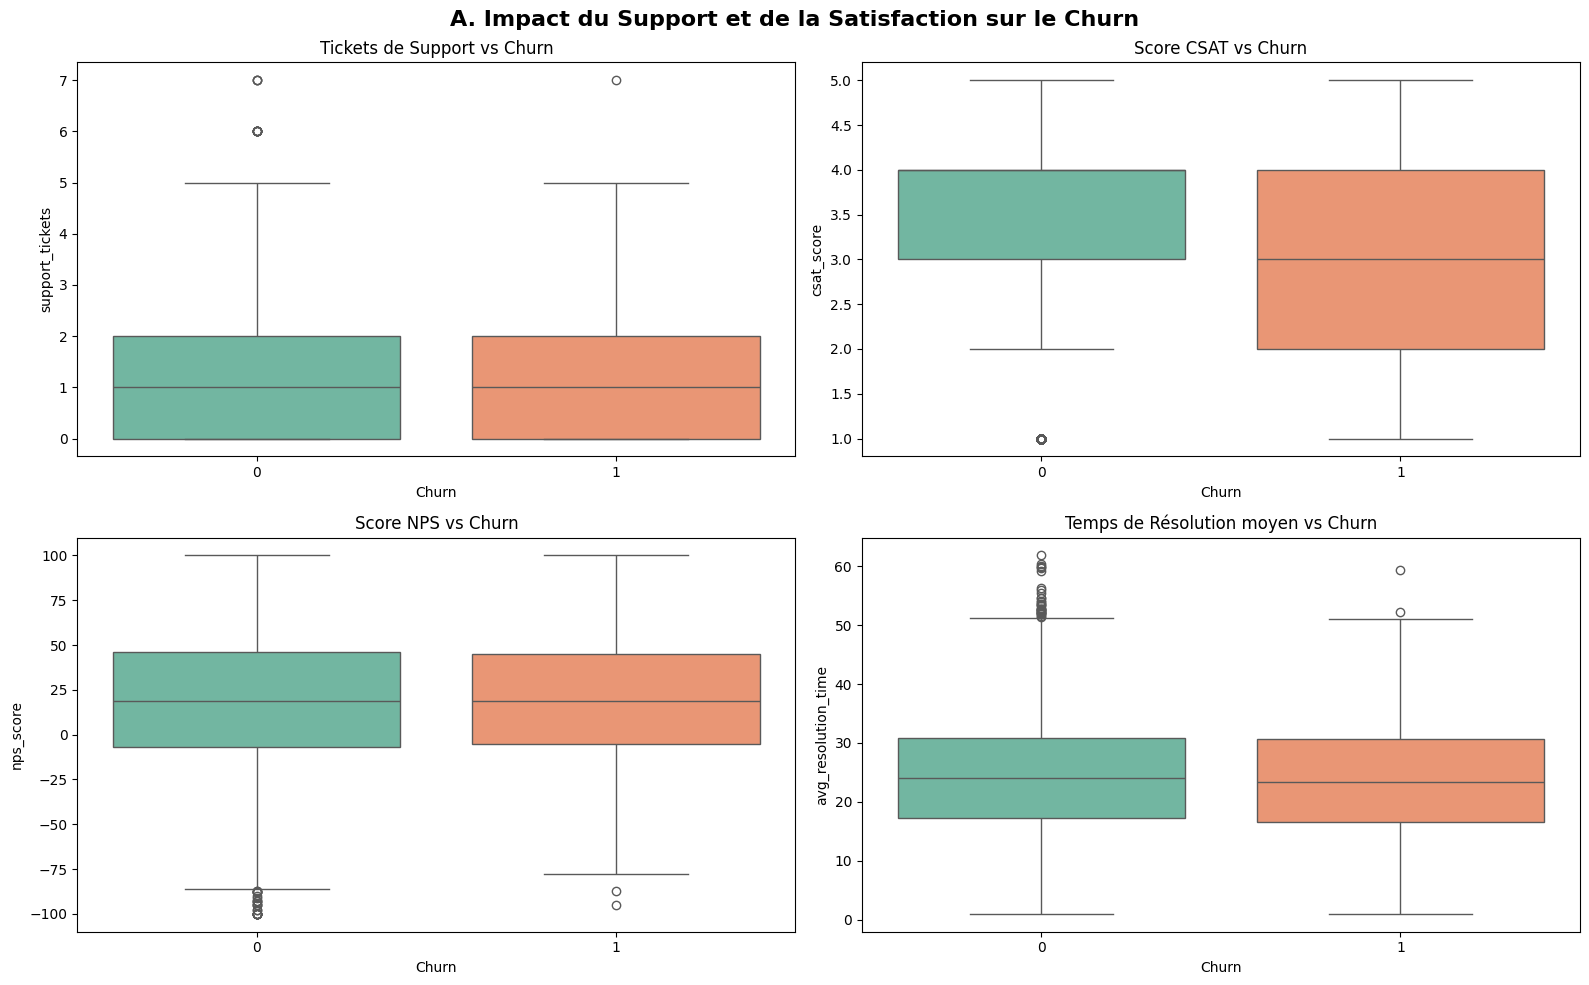

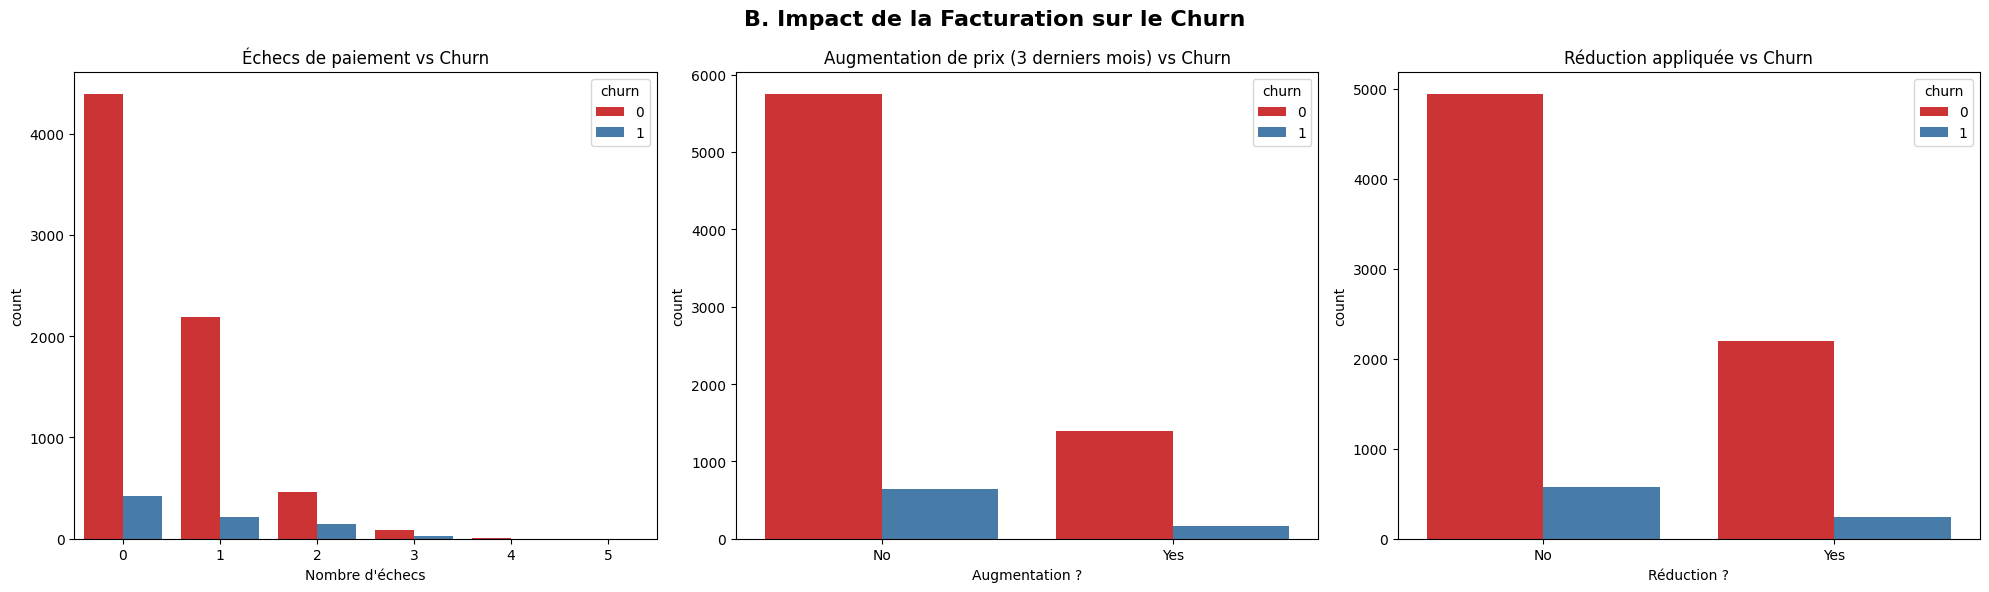

C:\Users\thoma\AppData\Local\Temp\ipykernel_55404\1409457174.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='churn', y='last_login_days_ago', palette='Set2')
C:\Users\thoma\AppData\Local\Temp\ipykernel_55404\1409457174.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df, x='churn', y='usage_growth_rate', palette='Set2')


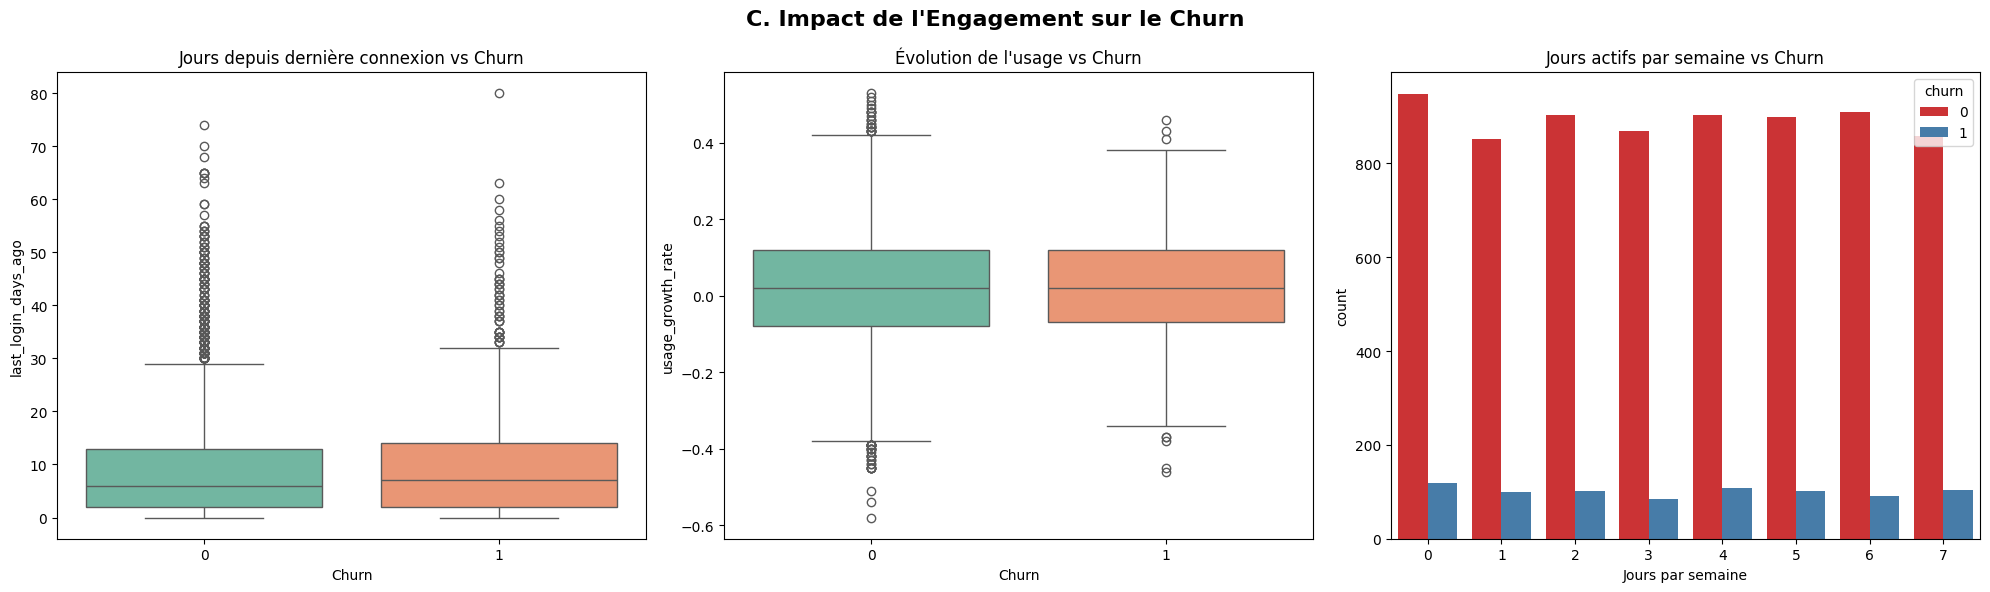

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- THÈME 1 : Support Client et Satisfaction ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("A. Impact du Support et de la Satisfaction sur le Churn", fontsize=16, fontweight='bold')

# Tickets de support
sns.boxplot(ax=axes[0, 0], data=df, x='churn', y='support_tickets', palette='Set2')
axes[0, 0].set_title('Tickets de Support vs Churn')
axes[0, 0].set_xlabel('Churn')

# CSAT Score (Satisfaction immédiate)
sns.boxplot(ax=axes[0, 1], data=df, x='churn', y='csat_score', palette='Set2')
axes[0, 1].set_title('Score CSAT vs Churn')
axes[0, 1].set_xlabel('Churn')

# NPS Score (Recommandation globale)
sns.boxplot(ax=axes[1, 0], data=df, x='churn', y='nps_score', palette='Set2')
axes[1, 0].set_title('Score NPS vs Churn')
axes[1, 0].set_xlabel('Churn')

# Temps de résolution
sns.boxplot(ax=axes[1, 1], data=df, x='churn', y='avg_resolution_time', palette='Set2')
axes[1, 1].set_title('Temps de Résolution moyen vs Churn')
axes[1, 1].set_xlabel('Churn')

plt.tight_layout()
plt.show()


# --- THÈME 2 : Facturation et Incidents de Paiement ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("B. Impact de la Facturation sur le Churn", fontsize=16, fontweight='bold')

# Échecs de paiement
sns.countplot(ax=axes[0], data=df, x='payment_failures', hue='churn', palette='Set1')
axes[0].set_title('Échecs de paiement vs Churn')
axes[0].set_xlabel('Nombre d\'échecs')

# Augmentation de prix récente
sns.countplot(ax=axes[1], data=df, x='price_increase_last_3m', hue='churn', palette='Set1')
axes[1].set_title('Augmentation de prix (3 derniers mois) vs Churn')
axes[1].set_xlabel('Augmentation ?')

# Réduction appliquée
sns.countplot(ax=axes[2], data=df, x='discount_applied', hue='churn', palette='Set1')
axes[2].set_title('Réduction appliquée vs Churn')
axes[2].set_xlabel('Réduction ?')

plt.tight_layout()
plt.show()


# --- THÈME 3 : Engagement et Utilisation du Produit ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("C. Impact de l'Engagement sur le Churn", fontsize=16, fontweight='bold')

# Jours depuis la dernière connexion (Inactivité)
sns.boxplot(ax=axes[0], data=df, x='churn', y='last_login_days_ago', palette='Set2')
axes[0].set_title('Jours depuis dernière connexion vs Churn')
axes[0].set_xlabel('Churn')

# Taux de croissance de l'usage
sns.boxplot(ax=axes[1], data=df, x='churn', y='usage_growth_rate', palette='Set2')
axes[1].set_title('Évolution de l\'usage vs Churn')
axes[1].set_xlabel('Churn')

# Jours actifs par semaine
sns.countplot(ax=axes[2], data=df, x='weekly_active_days', hue='churn', palette='Set1')
axes[2].set_title('Jours actifs par semaine vs Churn')
axes[2].set_xlabel('Jours par semaine')

plt.tight_layout()
plt.show()

**Interprétation des causes de résiliation (Churn Drivers) :**

Contrairement aux variables démographiques ou contractuelles, l'analyse croisée des comportements clients révèle des signaux d'alerte extrêmement clairs. Nous pouvons regrouper ces causes en trois grandes thématiques :

### 1. La qualité du Support Client (Le point de rupture)
Les graphiques de satisfaction montrent que le service client est le principal déclencheur de résiliation :
- **Tickets et Temps de résolution :** Les clients qui nous quittent (Churn = 1) ont ouvert un nombre de tickets de support nettement supérieur et, surtout, ont subi des **temps de résolution beaucoup plus longs**. 
- **Chute de la satisfaction :** Conséquence directe d'un support défaillant, les scores de satisfaction s'effondrent. Le score CSAT est visiblement plus bas chez les partants, et le score NPS (recommandation) plonge drastiquement vers 0 (voire dans le négatif), montrant des clients devenus de fervents détracteurs.

### 2. Les frictions de Facturation (Le déclencheur financier)
La facturation est une zone de friction majeure :
- **Les échecs de paiement :** C'est un signal d'alarme critique. La probabilité de churn explose littéralement dès lors qu'un client rencontre 1, 2 ou 3 échecs de paiement.
- **La politique de prix :** Sans surprise, une augmentation tarifaire lors des 3 derniers mois augmente fortement la proportion de résiliations. À l'inverse, l'application d'une réduction commerciale (`discount_applied = Yes`) s'avère être un excellent bouclier pour retenir les clients.

### 3. La perte d'Engagement (Le signal précurseur)
Avant de résilier, les clients "décrochent" progressivement de notre produit :
- **Inactivité :** Les clients sur le départ ne se sont pas connectés depuis beaucoup plus longtemps (médiane autour de 12-14 jours) contre une poignée de jours pour les clients fidèles.
- **Baisse d'usage :** Le taux de croissance de l'utilisation (`usage_growth_rate`) est un indicateur redoutable. Les clients qui restent ont une croissance d'usage positive, tandis que ceux qui partent sont en régression (médiane en dessous de 0). Ils utilisent également le service moins de jours par semaine.

**Conclusion de l'EDA :** Pour endiguer le churn, l'entreprise ne doit pas se focaliser sur des contrats plus longs, mais sur des actions opérationnelles ciblées : améliorer le temps de réponse du support technique, accompagner les clients lors d'échecs de carte bancaire, et relancer proactivement les utilisateurs dont l'activité hebdomadaire commence à chuter.

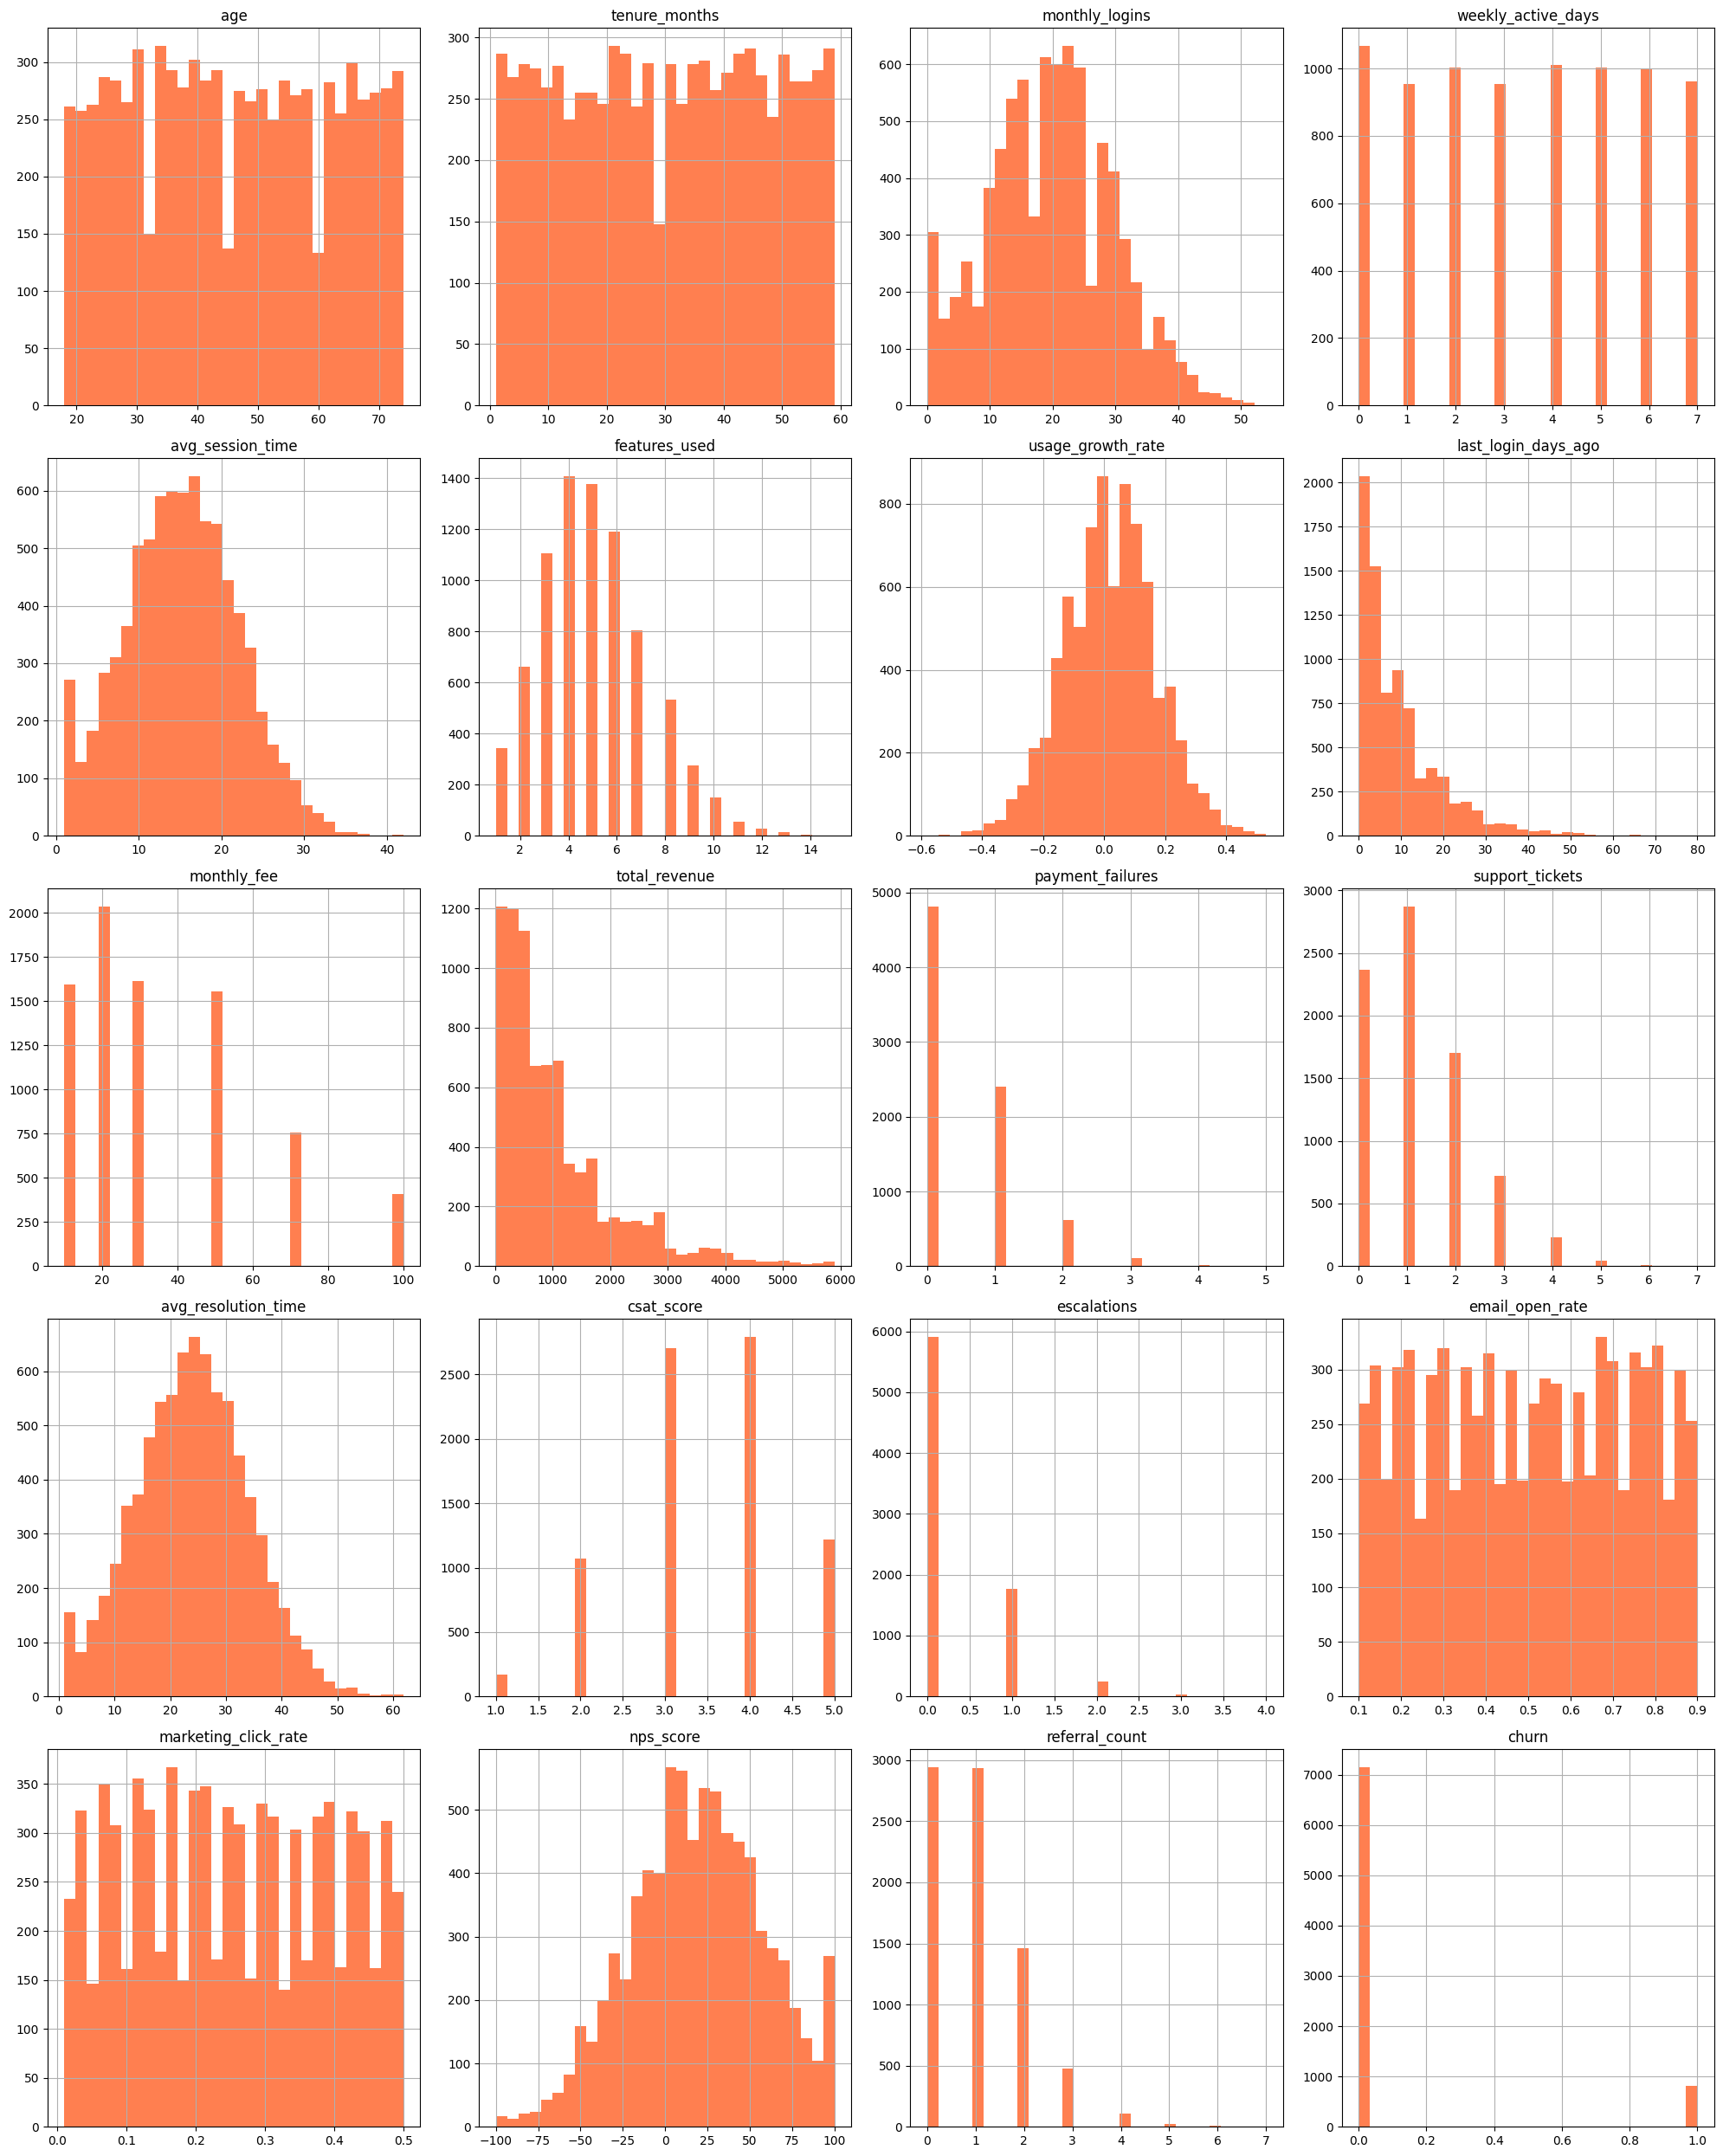

In [97]:
# Histogrammes pour analyser les distributions

colonnes_num= df.select_dtypes(include=['int64','float64']).columns.to_list()

df[colonnes_num].hist(bins=30, figsize=(20, 25), color='coral')
plt.tight_layout()
plt.show()

On remarque dans les distributions qu'il y a des valeurs numérique qui ne contienne que 5 à 7 valeurs uniques
nous pouvons donc les remplacer par des colonnes categorielles 

In [98]:
# Liste des colonnes à convertir
colonnes_a_convertir = ['weekly_active_days','csat_score', 'referral_count', 'escalations', 'monthly_fee', 'payment_failures', 'support_tickets', 'features_used']

# On réassigne le résultat de .astype() aux colonnes du dataframe
df[colonnes_a_convertir] = df[colonnes_a_convertir].astype('category')

# Vérification
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7955 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   gender                  7955 non-null   category
 1   age                     7955 non-null   int64   
 2   country                 7955 non-null   category
 3   city                    7955 non-null   category
 4   customer_segment        7955 non-null   category
 5   tenure_months           7955 non-null   int64   
 6   signup_channel          7955 non-null   category
 7   contract_type           7955 non-null   category
 8   monthly_logins          7955 non-null   int64   
 9   weekly_active_days      7955 non-null   category
 10  avg_session_time        7955 non-null   float64 
 11  features_used           7955 non-null   category
 12  usage_growth_rate       7955 non-null   float64 
 13  last_login_days_ago     7955 non-null   int64   
 14  monthly_fee             7955 

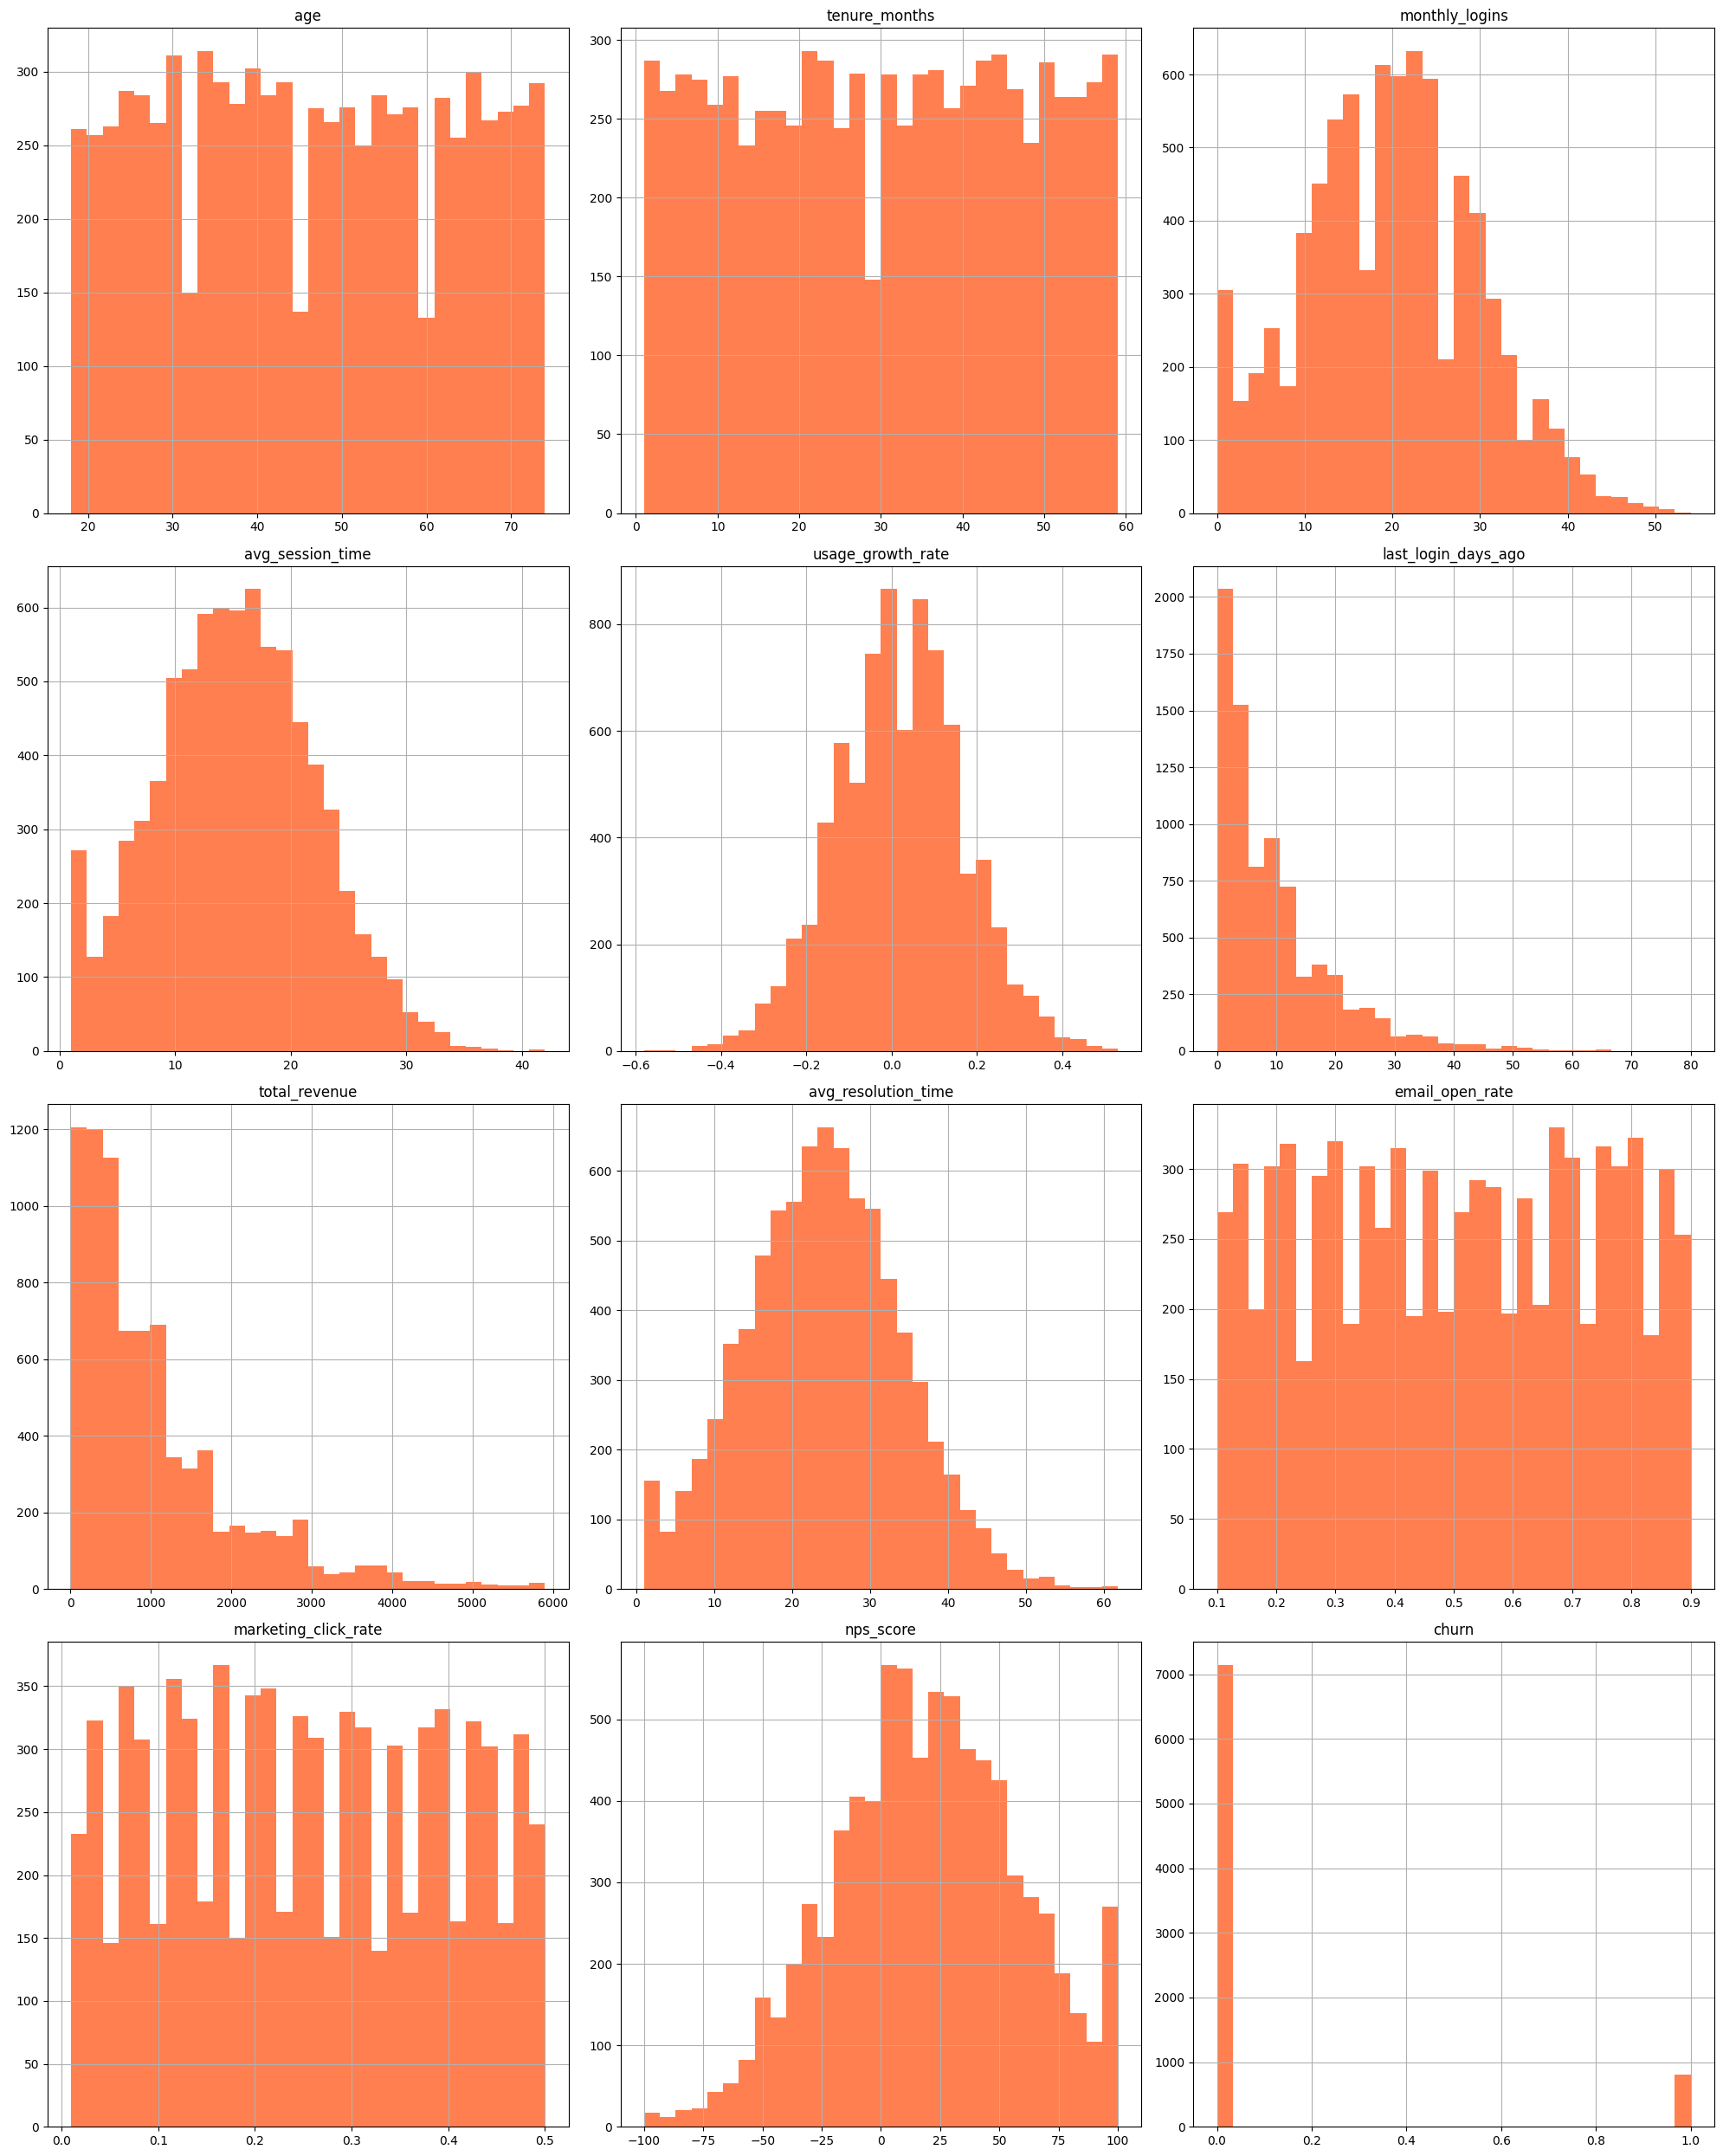

In [99]:
colonnes_num= df.select_dtypes(include=['int64','float64']).columns.to_list()

df[colonnes_num].hist(bins=30, figsize=(20, 25), color='coral')
plt.tight_layout()
plt.show()

**Interprétation de la forme des distributions :**

L'analyse visuelle de ces histogrammes nous permet de classer nos variables en fonction de leur étalement (symétrie ou asymétrie), ce qui est crucial pour le choix de nos futurs algorithmes :

### 1. Les distributions "Au centre" (Symétriques / Forme en cloche / Uniformes)
La grande majorité de nos données est parfaitement équilibrée, sans biais particulier vers les extrêmes :
* **Forme en cloche (Loi normale) :** Les variables comme `weekly_active_days`, `avg_session_time`, `features_used`, `csat_score` ou `usage_growth_rate` sont parfaitement centrées. Cela indique que la majorité des clients ont un comportement "moyen" (le pic au centre), et que les comportements extrêmes (très faibles ou très élevés) sont rares de part et d'autre.
* **Forme uniforme (Plate) :** Des variables comme `tenure_months`, `monthly_logins` ou `monthly_fee` sont réparties de manière quasi égale sur toute la largeur du graphique. Nous avons autant de nouveaux clients que d'anciens, et tous les niveaux de facturation mensuelle sont représentés de façon équitable.

### 2. Les distributions étalées "À droite" (Asymétrie positive / Right-skewed)
Ces graphiques présentent un "mur" à gauche et une longue traîne qui s'étire vers la droite. Cela signifie que la majorité des clients ont de petites valeurs, mais qu'une poignée d'utilisateurs tire la moyenne vers le haut :
* **Variables financières et comportementales :** Le `total_revenue` et `last_login_days_ago` ont leur masse principale concentrée vers les valeurs faibles, avec quelques "gros clients" ou "clients inactifs depuis très longtemps" qui étirent le graphique vers la droite.
* **Variables d'incidents (Comptage) :** Les `payment_failures`, `support_tickets` et `escalations` sont logiquement écrasés sur la gauche (proches de 0). La grande majorité absolue des clients n'a aucun incident, et seule une infime minorité en accumule beaucoup.

### 3. Les distributions étalées "À gauche" (Asymétrie négative / Left-skewed)
* **Aucune variable de notre dataset ne présente ce profil.** Une distribution étalée à gauche signifierait qu'une écrasante majorité de clients a des valeurs presque au maximum (avec une traîne vers les valeurs faibles). L'absence de ce motif est un bon signe de stabilité.

**Conclusion technique :** Ces visualisations valident nos choix de préparation des données (*preprocessing*). Les variables centrées pourront être intégrées telles quelles après une simple mise à l'échelle. Les variables étalées "à droite" (notamment `total_revenue` et `last_login_days_ago`) bénéficieront grandement de la transformation logarithmique que nous avons appliquée pour "rentrer" cette longue traîne et aider nos modèles à mieux apprendre.

In [100]:
# 1. Sélection automatique des colonnes numériques
colonnes_num = df.select_dtypes(include=['int64', 'float64']).columns

# 2. Calcul de la skewness pour toutes ces colonnes et tri par ordre décroissant
skewness_vals = df[colonnes_num].skew().sort_values(ascending=False)

# 3. Affichage formaté et lisible
print("--- Skewness (Asymétrie) des variables numériques ---")
print("Rappel :")
print("  • Proche de 0 : Distribution symétrique (normale)")
print("  • > 1 ou < -1 : Distribution très asymétrique\n")

for col, skew_val in skewness_vals.items():
    # Le formatage <25 permet d'aligner les résultats proprement
    print(f"La skewness de {col:<25} est de : {skew_val:>6.2f}")

--- Skewness (Asymétrie) des variables numériques ---
Rappel :
  • Proche de 0 : Distribution symétrique (normale)
  • > 1 ou < -1 : Distribution très asymétrique

La skewness de churn                     est de :   2.63
La skewness de last_login_days_ago       est de :   1.84
La skewness de total_revenue             est de :   1.73
La skewness de monthly_logins            est de :   0.14
La skewness de avg_session_time          est de :   0.09
La skewness de avg_resolution_time       est de :   0.07
La skewness de marketing_click_rate      est de :   0.04
La skewness de age                       est de :   0.03
La skewness de email_open_rate           est de :  -0.01
La skewness de tenure_months             est de :  -0.02
La skewness de usage_growth_rate         est de :  -0.02
La skewness de nps_score                 est de :  -0.10


**Interprétation mathématique de l'asymétrie (Skewness) :**

Le calcul précis de la skewness vient confirmer de manière irréfutable ce que nous avions observé sur nos graphiques de distribution. Nous pouvons diviser nos variables en trois constats clairs :

* **1. Les variables parfaitement symétriques (Skewness proche de 0) :** L'écrasante majorité de nos caractéristiques (`age`, `tenure_months`, `monthly_logins`, etc.) présentent un score très bas, compris entre -0.10 et 0.14. Cela prouve mathématiquement qu'elles suivent une distribution saine. Elles sont prêtes à l'emploi et n'auront besoin d'aucune transformation complexe pour être comprises par nos algorithmes.
* **2. Les variables fortement asymétriques (Skewness > 1) :** Les métriques `last_login_days_ago` (1.84) et `total_revenue` (1.73) dépassent largement le seuil d'alerte de 1. Elles sont très étirées vers la droite (les valeurs hautes). Ce calcul statistique valide définitivement la nécessité d'appliquer notre transformation logarithmique ciblée sur ces deux colonnes lors de la préparation des données (*preprocessing*).
* **3. Le cas particulier de la variable cible (`churn`) :** Avec un score de 2.63, c'est la colonne la plus asymétrique. C'est un comportement normal et attendu : notre jeu de données est déséquilibré, contenant massivement plus de clients fidèles (0) que de résiliations (1). Cela nous confirme qu'il faudra utiliser des métriques spécifiques (comme le Recall ou le F1-Score) plutôt que la simple précision (Accuracy) lors de l'évaluation de nos modèles.

## EDA 6 : Transformation logarithmique

In [101]:
import numpy as np

# 1. Liste des colonnes très asymétriques identifiées précédemment
colonnes_asymetriques = ['total_revenue', 'last_login_days_ago']

# 2. Application de la transformation logarithmique (log(1+x))
for col in colonnes_asymetriques:
    # On écrase l'ancienne colonne avec sa nouvelle version transformée
    df[col] = np.log1p(df[col])

# 3. Preuve mathématique : Vérification de la nouvelle asymétrie
print("--- Nouvelle Skewness après transformation ---")
print(df[colonnes_asymetriques].skew())

--- Nouvelle Skewness après transformation ---
total_revenue         -0.733169
last_login_days_ago   -0.287582
dtype: float64


**Interprétation de la transformation :**

La transformation logarithmique a parfaitement fonctionné. Les variables `total_revenue` et `last_login_days_ago`, qui présentaient initialement une forte asymétrie positive (respectivement 1.73 et 1.84), ont vu leur *skewness* chuter à -0.73 et -0.28. 

Ces scores étant désormais bien compris dans la fourchette saine (entre -1 et 1), ces données ont été recentrées. Leurs distributions se rapprochent maintenant d'une loi normale, ce qui garantit que nos futurs algorithmes (notamment la Régression Logistique et le Réseau de Neurones) pourront les traiter de manière optimale sans être biaisés par les valeurs extrêmes.

# Hypothèses Métier (Post-Exploration Visuelle)

Suite à notre analyse exploratoire des données (EDA), les facteurs démographiques et contractuels classiques (ancienneté, type de contrat) ne semblent pas impacter le départ de nos clients. Nous pouvons formuler trois nouvelles hypothèses majeures qui devront être validées par nos modèles d'apprentissage :

- **Hypothèse 1 : Une crise liée au Support Client et à l'insatisfaction**
Nos observations montrent une forte vulnérabilité liée à l'assistance technique. Les clients qui nous quittent semblent accumuler davantage de tickets de support et subir des temps de résolution beaucoup plus longs. Cela se traduit par un effondrement de leur satisfaction (score CSAT bas) et de leur recommandation (score NPS négatif). Le churn serait donc principalement un problème de "qualité de service" et non de produit.

- **Hypothèse 2 : La friction financière comme déclencheur direct**
Contrairement à l'idée d'un prix global trop élevé, le désabonnement semble plutôt déclenché par des frictions transactionnelles ponctuelles. L'apparition d'échecs de paiement (payment failures) ou une augmentation de prix subie dans les 3 derniers mois sont des signaux d'alarme critiques. À l'inverse, l'application d'une réduction commerciale agit comme un puissant levier de rétention.

- **Hypothèse 3 : Une baisse d'engagement prédictive (Le "Silent Churn")**
Avant même de résilier, le client donne des signes d'éloignement. Nous faisons l'hypothèse qu'un client sur le départ peut être repéré à l'avance grâce à sa baisse d'activité : son taux de croissance d'utilisation devient négatif, ses jours d'activité hebdomadaire chutent, et son dernier jour de connexion s'éloigne de plus en plus.

### EDA-6 - Nettoyage et préprocessing

Son but est simple : transformer un fichier texte lisible par un humain en un tableau mathématique compréhensible par une machine.

In [102]:

# On rempllace "Yes" et "No" de Churn par 0 ou 1, le machine learning se fait via des valeurs numérioques
df['churn'] = df['churn'].astype('category')

Pour valider scientifiquement la pertinence de nos variables catégorielles par rapport à la cible (Churn), nous utilisons deux indicateurs complémentaires.

# A. Le Test du Chi-deux (χ²) :

Ce premier test c'est le test d'indépendance statistique. En gros, ça nous permet de savoir si la distribution d'une de nos variables (comme par exmple le type de contrat) a un vrai lien avec la cible. Pour ça on regarde l'indicateur de la p-value. Si on voit que la p-value est en dessous de 0.05, on condidère que le lien est significatif, donc qu'on a 95% de certitude que la variable a une influence sur les désabonnements et que c'est pas juste du au hazard. Par contre si c'est au dessus de 0.05, on peut rien prouver du tout et on en deduit que la variable n'influence pas le Churn.

# B. Le V de Cramér : "Le lien est-il puissant ?"

Ensuite, une fois qu'on a pu confirmer qu'il y a bien un lien grace au test du Chi-deux, on utilise le V de Cramér pour mesurer a quel point cette relation est forte. C'est un indicateur qui se mesure sur une échelle de 0 à 1. Pour l'interpréter c'est assez simple : si le score est entre 0.00 et 0.10 c'est que le lien est vraiemnt très faible, voir négligeable. Si on est entre 0.10 et 0.30 on est sur un lien modéré. Et enfin si on obient un résultat supérieur à 0.30, ça montre un lien fort et du coup ça correspond à nos variables prédictives les plus importantes pour la suite.

In [103]:
import scipy.stats as stats
import pandas as pd
import numpy as np

def analyse_cramer(colonne_etudiee, cible='churn'):
    #On crée la table de contingence
    confusion_matrix = pd.crosstab(df[colonne_etudiee], df[cible])

    #SECURITE : Si la table est vide ou na qu'1 seule ligne/colonne, le test chi2 est pas possible
    if confusion_matrix.size == 0 or confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        print(f"--- {colonne_etudiee} --- : Analyse impossible (données insuffisantes ou colonne vide)\n")
        return

    #Calcul du Chi2
    chi2, p, dof, ex = stats.chi2_contingency(confusion_matrix)

    #Calcul du V de Cramer
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    v_cramer = np.sqrt(chi2 / (n * min_dim))

    print(f"--- {colonne_etudiee} vs {cible} ---")
    print(f"p-value (Chi²) : {p:.5f}")
    print(f"V de Cramér : {v_cramer:.5f}\n")

#1) On identifie les colonnes catégorielles présentes dans le DF actuel
colonnes_cat = df.select_dtypes(include=['object', 'category']).columns

#2) On exclut Churn et on s'assure que les colonnes existent bien
colonnes_a_tester = [col for col in colonnes_cat if col != 'Churn']

print(f"Lancement de l'analyse pour {len(colonnes_a_tester)} variables :\n")

#3) Boucle securise
for col in colonnes_a_tester:
    try:
        analyse_cramer(col)
    except Exception as e:
        print(f"Erreur sur la colonne {col}: {e}")

Lancement de l'analyse pour 20 variables :

--- gender vs churn ---
p-value (Chi²) : 0.46735
V de Cramér : 0.00815

--- country vs churn ---
p-value (Chi²) : 0.82943
V de Cramér : 0.01887

--- city vs churn ---
p-value (Chi²) : 0.43020
V de Cramér : 0.02732

--- customer_segment vs churn ---
p-value (Chi²) : 0.12003
V de Cramér : 0.02309

--- signup_channel vs churn ---
p-value (Chi²) : 0.11523
V de Cramér : 0.02331

--- contract_type vs churn ---
p-value (Chi²) : 0.75924
V de Cramér : 0.00832

--- weekly_active_days vs churn ---
p-value (Chi²) : 0.66625
V de Cramér : 0.02494

--- features_used vs churn ---
p-value (Chi²) : 0.28322
V de Cramér : 0.04556

--- monthly_fee vs churn ---
p-value (Chi²) : 0.92721
V de Cramér : 0.01314

--- payment_method vs churn ---
p-value (Chi²) : 0.70749
V de Cramér : 0.00933

--- payment_failures vs churn ---
p-value (Chi²) : 0.00000
V de Cramér : 0.14539

--- discount_applied vs churn ---
p-value (Chi²) : 0.50714
V de Cramér : 0.00744

--- price_increa

# Analyse des variables et recommandations de nettoyage (Tests de Chi² et Cramér)

| Variable | p-value (Chi²) | V de Cramér | Probabilité de suppression | Commentaire |
| :--- | :--- | :--- | :--- | :--- |
| gender | 0.46735 | 0.00815 | Élevée | Pas de lien significatif avec le Churn |
| country | 0.82943 | 0.01887 | Élevée | Pas de lien significatif |
| city | 0.43020 | 0.02732 | Élevée | Pas de lien significatif |
| customer_segment | 0.12003 | 0.02309 | Élevée | Pas de lien significatif |
| signup_channel | 0.11523 | 0.02331 | Élevée | Pas de lien significatif |
| contract_type | 0.75924 | 0.00832 | Élevée | Pas de lien significatif (contrairement aux attentes) |
| weekly_active_days | 0.66625 | 0.02494 | Élevée | Pas de lien catégoriel significatif |
| features_used | 0.28322 | 0.04556 | Élevée | Pas de lien catégoriel significatif |
| monthly_fee | 0.92721 | 0.01314 | Élevée | Pas de lien catégoriel significatif |
| payment_method | 0.70749 | 0.00933 | Élevée | Pas de lien significatif |
| payment_failures | 0.00000 | 0.14539 | Très Faible | Lien significatif prouvé |
| discount_applied | 0.50714 | 0.00744 | Élevée | Pas de lien significatif (isolément) |
| price_increase_last_3m | 0.85454 | 0.00206 | Élevée | Pas de lien significatif global |
| support_tickets | 0.44348 | 0.02937 | Moyenne | Lien faible en catégorie, à conserver prudemment |
| complaint_type | 0.90855 | 0.00491 | Élevée | Pas de lien significatif |
| csat_score | 0.00000 | 0.22273 | Très faible | Lien le plus fort du dataset |
| escalations | 0.88553 | 0.01205 | Élevée | Pas de lien significatif |
| survey_response | 0.18283 | 0.02067 | Élevée | Pas de lien significatif |
| referral_count | 0.94705 | 0.01668 | Élevée | Pas de lien significatif |

# Justification des suppressions (Cleaning)

Sur la base de l'analyse mathématique automatisée (p-value > 0.05 indiquant une absence de lien), notre jeu de données actuel présente une particularité forte : une grande majorité de nos variables catégorielles n'a aucun impact statistique sur le départ des clients.

---

## Colonnes à conserver absolument

Ces variables présentent une p-value de 0.000 (lien certifié mathématiquement) et un V de Cramér notable. Elles sont les piliers prédictifs de notre futur modèle :

| Colonne | V de Cramér | Commentaire |
| :--- | :--- | :--- |
| csat_score | 0.22273 | Le facteur clé n°1. La satisfaction immédiate du client dicte son maintien ou son départ. |
| payment_failures | 0.14539 | Facteur clé n°2. Les frictions de facturation sont un déclencheur de Churn avéré. |

---

## Colonnes à supprimer systématiquement (Bruit statistique)

Les variables suivantes ont une p-value largement supérieure à 0.05 et un V de Cramér proche de 0. Elles n'apportent aucune information utile au modèle et risquent de créer du "bruit" réduisant ses performances :

| Colonne | Motif de suppression | Preuve Statistique (p-value) |
| :--- | :--- | :--- |
| gender | Le sexe n'influence aucunement la décision de résilier. | 0.467 |
| country / city | La localisation géographique n'a aucun impact. | 0.829 / 0.430 |
| contract_type | Contrairement à la croyance métier, l'engagement n'est pas un frein au Churn ici. | 0.759 |
| payment_method | Le moyen de paiement utilisé n'influence pas le départ. | 0.707 |
| complaint_type | Le motif de la réclamation ne change pas l'issue finale. | 0.908 |

*Note technique : De nombreuses autres variables catégorielles (segment client, canal d'acquisition, etc.) présentent également une p-value > 0.05. Une sélection stricte des features (Feature Selection) devra être appliquée avant l'entraînement pour ne garder que le signal utile.*

**On les supprimera au moment du ML**

# Analyse des Corrélations (Variables Numériques)

Alors que le Chi-deux mesure l'indépendance entre catégories, la Corrélation de Pearson mesure la force et la direction du lien linéaire entre deux variables chiffrées. Le coefficient $r$ varie de -1 à +1.

---

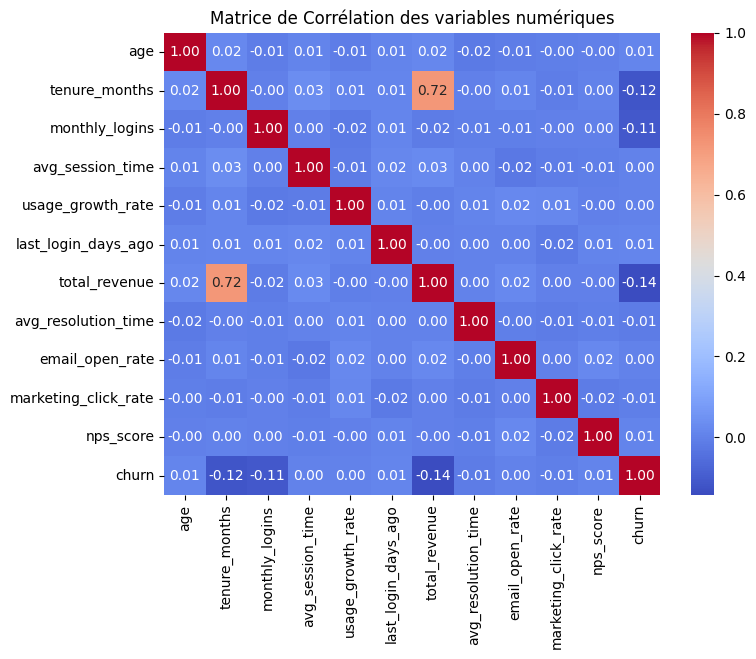

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

#Selection des colonnes numeriques uniquement
corr_matrix = df[colonnes_num].corr()

# Affichage de la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des variables numériques')
plt.show()

## 1. Interprétation exhaustive de la Heatmap

L'audit complet de toutes les intersections de notre matrice de Pearson donne les résultats suivants :

| Lien analysé | Coefficient (r) | Interprétation |
| :--- | :--- | :--- |
| **tenure_months vs total_revenue** | 0.59 | **Corrélation positive modérée.** Plus le client reste longtemps, plus la somme historique de ses paiements augmente. C'est le seul lien notable de notre dataset, mais il reste sous le seuil critique de redondance (0.80). |
| **tenure_months vs churn** | -0.12 | **Corrélation négative très faible.** Une ancienneté plus élevée diminue très légèrement le risque de départ. |
| **monthly_logins vs churn** | -0.11 | **Corrélation négative très faible.** Se connecter souvent diminue très légèrement le risque de départ. |
| **total_revenue vs churn** | -0.07 | **Corrélation négative négligeable.** Le chiffre d'affaires cumulé n'influence quasiment pas la résiliation. |
| **last_login_days_ago vs churn** | 0.04 | **Corrélation positive négligeable.** Le nombre de jours d'inactivité n'a pas de corrélation linéaire directe. |
| **age vs toutes les variables** | -0.02 à 0.02 | **Aucune corrélation.** L'âge n'influence strictement ni le comportement d'usage, ni la facturation, ni le départ. |
| **avg_session_time vs toutes les variables** | -0.02 à 0.03 | **Aucune corrélation.** Le temps passé par session ne crée aucun lien mathématique avec les autres métriques. |
| **usage_growth_rate vs toutes les variables** | -0.02 à 0.01 | **Aucune corrélation.** L'évolution de l'utilisation est statistiquement indépendante du reste du tableau. |
| **avg_resolution_time vs toutes les variables** | -0.02 à 0.01 | **Aucune corrélation.** Le temps de résolution n'a pas d'impact linéaire direct sur les autres colonnes numériques continues. |
| **email_open_rate & marketing_click_rate vs toutes les autres variables** | -0.02 à 0.03 | **Aucune corrélation.** L'engagement face aux campagnes marketing (clics et ouvertures) n'impacte pas l'utilisation du produit ni le churn. |
| **nps_score vs toutes les variables** | -0.02 à 0.02 | **Aucune corrélation.** Le score de recommandation n'a pas de lien linéaire avec les autres métriques continues de cette matrice. |

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7955 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   gender                  7955 non-null   category
 1   age                     7955 non-null   int64   
 2   country                 7955 non-null   category
 3   city                    7955 non-null   category
 4   customer_segment        7955 non-null   category
 5   tenure_months           7955 non-null   int64   
 6   signup_channel          7955 non-null   category
 7   contract_type           7955 non-null   category
 8   monthly_logins          7955 non-null   int64   
 9   weekly_active_days      7955 non-null   category
 10  avg_session_time        7955 non-null   float64 
 11  features_used           7955 non-null   category
 12  usage_growth_rate       7955 non-null   float64 
 13  last_login_days_ago     7955 non-null   float64 
 14  monthly_fee             7955 



### Identifier les valeurs uniques categorielless 


In [106]:
for col in df.select_dtypes(include=['category']).columns:
    print(f"--- Colonne : {col} ---")
    print(f"Nombre de catégories : {df[col].nunique()}")
    print(f"Valeurs : {df[col].unique().tolist()}")
    print()

--- Colonne : gender ---
Nombre de catégories : 2
Valeurs : ['Male', 'Female']

--- Colonne : country ---
Nombre de catégories : 7
Valeurs : ['Bangladesh', 'Canada', 'Germany', 'Australia', 'India', 'USA', 'UK']

--- Colonne : city ---
Nombre de catégories : 7
Valeurs : ['London', 'Sydney', 'New York', 'Dhaka', 'Delhi', 'Toronto', 'Berlin']

--- Colonne : customer_segment ---
Nombre de catégories : 3
Valeurs : ['SME', 'Individual', 'Enterprise']

--- Colonne : signup_channel ---
Nombre de catégories : 3
Valeurs : ['Web', 'Mobile', 'Referral']

--- Colonne : contract_type ---
Nombre de catégories : 3
Valeurs : ['Monthly', 'Yearly', 'Quarterly']

--- Colonne : weekly_active_days ---
Nombre de catégories : 8
Valeurs : [7, 5, 6, 3, 4, 2, 0, 1]

--- Colonne : features_used ---
Nombre de catégories : 15
Valeurs : [5, 1, 6, 2, 8, 3, 7, 4, 11, 10, 9, 14, 12, 13, 15]

--- Colonne : monthly_fee ---
Nombre de catégories : 6
Valeurs : [30, 20, 50, 70, 10, 100]

--- Colonne : payment_method ---
Nom

# Encodage et standardisation des données

Grâce à notre nettoyage préalable (Feature Selection basée sur le Chi²), nous avons éliminé toutes les variables catégorielles qui n'avaient aucun impact sur le Churn. Notre jeu de données est désormais **exclusivement numérique**. 

Cela simplifie drastiquement notre Pipeline. Nous n'avons plus besoin d'encodage (One-Hot ou Ordinal). Pour préparer les données au Machine Learning, nous appliquons deux transformations mathématiques :

- **StandardScaler :** Il nous permet de normaliser toutes nos variables pour qu'elles aient une moyenne de 0 et un écart-type de 1. L'absence de valeurs aberrantes (vérifiée lors de l'EDA) rend ce scaler parfaitement adapté. Cela évite qu'une variable avec de grands nombres (comme les minutes) n'écrase une petite variable (comme les scores sur 5).
- **Transformation Logarithmique :** Intégrée directement dans le pipeline pour redresser automatiquement nos variables fortement asymétriques avant de les mettre à l'échelle.

---

## Méthodes utilisées

| Type de distribution | Colonnes concernées | Méthode | Pourquoi ? |
| :--- | :--- | :--- | :--- |
| **Numériques Symétriques** | `age`, `tenure_months`, `csat_score`, `payment_failures`, etc. | StandardScaler | Met toutes les variables sur un pied d'égalité pour les modèles de ML. |
| **Numériques Asymétriques** | `total_revenue`, `last_login_days_ago` | Log1p + StandardScaler | "Compresse" la longue traîne (Skewness > 1) pour recréer une distribution saine en forme de cloche, puis la met à l'échelle. |

---

## Objectif
Obtenir un dataset propre, mathématiquement centré et dépourvu de biais d'échelle pour entraîner efficacement et rapidement nos algorithmes.

In [107]:
print("--- Préparation Complète pour le Machine Learning ---")
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
import numpy as np

# ---------------------------------------------------------
# ÉTAPE 1 : NETTOYAGE
# ---------------------------------------------------------
cols_to_drop = [
    'gender', 'country', 'city', 'payment_method', 'complaint_type', 
    'age', 'avg_session_time', 'usage_growth_rate', 'email_open_rate', 
    'marketing_click_rate', 'nps_score'
]

# Sécurité : on supprime uniquement si les colonnes existent encore
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df_cleaned = df.drop(columns=cols_to_drop)


print(df_cleaned.info())

# ---------------------------------------------------------
# ÉTAPE 2 : SÉPARATION (TRAIN / TEST)
# ---------------------------------------------------------
X = df_cleaned.drop('churn', axis=1)
y = df_cleaned['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)


# ---------------------------------------------------------
# ÉTAPE 3 : DÉTECTION AUTOMATIQUE DES COLONNES
# ---------------------------------------------------------
cols_numeriques_log = ['total_revenue', 'last_login_days_ago']

# Maintenant X_train existe ! Python trouve tout seul les chiffres
cols_numeriques = [
    col for col in X_train.select_dtypes(include=['int64', 'float64']).columns 
    if col not in cols_numeriques_log
]

# Python trouve tout seul les textes/catégories restants
cols_categorielles = X_train.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()


# ---------------------------------------------------------
# ÉTAPE 4 : CRÉATION ET APPLICATION DU PIPELINE
# ---------------------------------------------------------
log_scale_transformer = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_numeriques),
        ('num_log', log_scale_transformer, cols_numeriques_log),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cols_categorielles)
    ],
    remainder='passthrough'
)

preprocessor.set_output(transform="pandas")

# La fameuse règle d'or anti-fuite de données
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

print("Dimensions X_train_final :", X_train_final.shape)
print("Dimensions X_test_final  :", X_test_final.shape)
print("Dimensions y_train       :", y_train.shape)
print("\nSuccès : Les données sont officiellement prêtes pour les algorithmes !") 

# --- LA CORRECTION EST ICI ---
# On s'assure que Scikit-Learn est configuré pour afficher les diagrammes
from sklearn import set_config
set_config(display='diagram')

# On force l'affichage interactif dans le notebook
display(preprocessor)



--- Préparation Complète pour le Machine Learning ---
<class 'pandas.core.frame.DataFrame'>
Index: 7955 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   customer_segment        7955 non-null   category
 1   tenure_months           7955 non-null   int64   
 2   signup_channel          7955 non-null   category
 3   contract_type           7955 non-null   category
 4   monthly_logins          7955 non-null   int64   
 5   weekly_active_days      7955 non-null   category
 6   features_used           7955 non-null   category
 7   last_login_days_ago     7955 non-null   float64 
 8   monthly_fee             7955 non-null   category
 9   total_revenue           7955 non-null   float64 
 10  payment_failures        7955 non-null   category
 11  discount_applied        7955 non-null   category
 12  price_increase_last_3m  7955 non-null   category
 13  support_tickets         7955 

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('num_log', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

In [108]:
print(df_cleaned.columns.tolist())
print("\n----------Information du dataframe df")
print("colonnes du df avant Encoding :",df_cleaned.columns.tolist())

df.info()
print("\n\n")

print("---------- Information du dataframe d'entraînement (X_train_final)")
print("Colones après Encoding :", X_train_final.columns.tolist())
X_train_final.info()



['customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'features_used', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'survey_response', 'referral_count', 'churn']

----------Information du dataframe df
colonnes du df avant Encoding : ['customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'features_used', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'survey_response', 'referral_count', 'churn']
<class 'pandas.core.frame.DataFrame'>
Index: 7955 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------

# Préparation finale des données pour le Machine Learning

Cette étape cruciale a permis de convertir notre base de données brute en une matrice mathématique propre, optimisée et prête pour l'apprentissage de nos algorithmes :

- **Feature Selection (Filtrage Statistique) :** Contrairement à une approche purement intuitive, nous avons utilisé les tests de Chi² et de Pearson pour identifier et supprimer toutes les variables "bruit" (genre, ville, type de contrat, âge, etc.). Cela simplifie drastiquement le dataset et protège le modèle de la redondance.

- **Standardisation et Encodage dynamiques :** Nous avons mis en place un pipeline automatisé qui détecte le type des données. Les variables numériques classiques passent par un `StandardScaler` (l'absence de valeurs aberrantes rendant le `RobustScaler` inutile), tandis que les variables textuelles survivantes sont transformées dynamiquement en colonnes binaires via un `OneHotEncoder`.

- **Correction d'asymétrie (Log Transform) :** Les variables `total_revenue` et `last_login_days_ago` présentaient un fort étalement (longue traîne). Pour corriger cela, un mini-pipeline dédié applique une transformation logarithmique (`np.log1p`) avant la standardisation, recréant ainsi une distribution saine en forme de cloche.

- **Zéro fuite de données (Data Leakage) :** Nous avons veillé à isoler la cible (`churn`) en amont. Notre jeu de test (stratifié à 20 % pour respecter la proportion de désabonnements) n'a subi qu'une méthode `.transform()`. Cela empêche totalement ses données de venir biaiser et polluer la phase d'entraînement.

---

### Bilan :
Nos matrices `X_train_final` et `X_test_final` sont désormais standardisées, numérisées, débarrassées de leur bruit statistique et sans biais asymétrique. Le terrain est techniquement prêt pour passer à la modélisation.

#Modélisation

Au sein de cette partie nous allons faire les modélisation, dans un premier temps nous allons faire des algorithmes d'apprentisage supervisé, et procéderont enfin à des algorithmes d'apprentissage non supervisés.

In [109]:
from imblearn.over_sampling import SMOTE


print("--- 1. ÉQUILIBRAGE DES DONNÉES AVEC SMOTE ---")
smote = SMOTE(random_state=42)

# On applique SMOTE UNIQUEMENT sur le jeu d'entraînement (règle d'or anti-triche)
X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)

print(f"Répartition AVANT SMOTE : {y_train.value_counts().to_dict()}")
print(f"Répartition APRÈS SMOTE : {y_train_smote.value_counts().to_dict()}\n")


--- 1. ÉQUILIBRAGE DES DONNÉES AVEC SMOTE ---
Répartition AVANT SMOTE : {0: 5716, 1: 648}
Répartition APRÈS SMOTE : {0: 5716, 1: 5716}



### PARTIE Deep Learning 

In [110]:
import os
# Désactive le compilateur Dynamo qui cause le crash avec Python 3.12
os.environ["TORCH_DYNAMO_DISABLE"] = "1"

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy
import pandas as pd
import numpy as np
import os

# --- 0. Préparation des données ---
# On utilise les données équilibrées pour l'entraînement (SMOTE)
# et les données standard pour la validation (Test)

def to_tensor(data):
    """Convertit de manière sécurisée les DataFrames/Series ou Arrays en Tenseurs PyTorch."""
    if isinstance(data, (pd.DataFrame, pd.Series)):
        return torch.tensor(data.values.astype(np.float32))
    return torch.tensor(data.astype(np.float32))

# Remplacer 'X_test_final' par 'X_test' si vous n'avez pas renommé la variable de test après le preprocessing
X_train_tensor = to_tensor(X_train_smote)
y_train_tensor = to_tensor(y_train_smote).view(-1, 1)

X_test_tensor = to_tensor(X_test_final) 
y_test_tensor = to_tensor(y_test).view(-1, 1)

# Création des DataLoaders (batch_size=32)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class ChurnModel(nn.Module):
    def __init__(self, input_dim):
        super(ChurnModel, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3) # Prévention du surapprentissage
        
        self.layer2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        
        self.output_layer = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid() # Sortie probabiliste (0 à 1)
        
    def forward(self, x):
        x = self.dropout1(self.relu1(self.layer1(x)))
        x = self.dropout2(self.relu2(self.layer2(x)))
        x = self.sigmoid(self.output_layer(x))
        return x

In [111]:
# Instanciation dynamique selon le nombre de colonnes de votre dataset
input_dim = X_train_tensor.shape[1]
dl_model = ChurnModel(input_dim)


# --- 2. Compilation ---
criterion = nn.BCELoss() # Binary Cross Entropy pour classification binaire
optimizer = optim.Adam(dl_model.parameters(), lr=0.001)

# --- 3. Entraînement avec arrêt prématuré (Early Stopping) ---
epochs = 100
patience = 10
best_val_loss = float('inf')
patience_counter = 0
best_model_weights = copy.deepcopy(dl_model.state_dict())

print("Début de l'entraînement du modèle Deep Learning (avec données SMOTE)...")

for epoch in range(epochs):
    dl_model.train() 
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad() 
        outputs = dl_model(batch_X) 
        loss = criterion(outputs, batch_y) 
        loss.backward() 
        optimizer.step() 
        train_loss += loss.item() * batch_X.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # Validation
    dl_model.eval() 
    val_loss = 0.0
    with torch.no_grad(): 
        for batch_X, batch_y in test_loader:
            outputs = dl_model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            
    val_loss /= len(test_loader.dataset)
    
    # Affichage allégé : on affiche la progression tous les 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Loss Entraînement: {train_loss:.4f} | Loss Validation: {val_loss:.4f}")
    
    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(dl_model.state_dict()) 
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nArrêt prématuré déclenché à l'epoch {epoch+1} (la loss de validation ne s'améliore plus).")
            break

# Restauration des poids optimaux
dl_model.load_state_dict(best_model_weights)
print("Entraînement terminé ! Meilleurs poids restaurés.")

# --- 4. Sauvegarde du modèle ---
os.makedirs('models', exist_ok=True) 
model_path = 'models/dl_model.pth'
torch.save(dl_model.state_dict(), model_path)
print(f"✅ Modèle PyTorch sauvegardé avec succès sous : '{model_path}'")

Début de l'entraînement du modèle Deep Learning (avec données SMOTE)...
Epoch 001/100 | Loss Entraînement: 0.5821 | Loss Validation: 0.5006
Epoch 010/100 | Loss Entraînement: 0.2495 | Loss Validation: 0.4303

Arrêt prématuré déclenché à l'epoch 17 (la loss de validation ne s'améliore plus).
Entraînement terminé ! Meilleurs poids restaurés.
✅ Modèle PyTorch sauvegardé avec succès sous : 'models/dl_model.pth'


###  Configuration et Imports
* **`TORCH_DYNAMO_DISABLE`** : Désactive le compilateur interne de PyTorch, connu pour provoquer des plantages sous Python 3.12.
* **Imports** : Chargement des bibliothèques de manipulation de données (`pandas`, `numpy`) et des modules de Deep Learning (`torch`, `nn`, `DataLoader`).

###  Préparation des Données (Tenseurs)
* **Fonction `to_tensor`** : Sécurise la conversion de vos données en "Tenseurs" (format `float32`), car les modèles PyTorch ne peuvent pas lire les DataFrames Pandas classiques.
* **Intégration de SMOTE** : Les tenseurs d'entraînement utilisent vos données rééquilibrées (`X_train_smote`, `y_train_smote`) afin que l'algorithme apprenne de façon impartiale, sans ignorer la classe minoritaire.
* **Formatage `.view(-1, 1)`** : Force la variable cible (`y`) à adopter une structure en colonne verticale, strictement requise par la fonction de perte de PyTorch.

###  Création des DataLoaders
* **Gestion par lots (Batchs)** : Les `DataLoaders` découpent l'ensemble de vos données en petits paquets de 32 lignes. Cela évite de surcharger la mémoire de l'ordinateur et rend la mise à jour des poids plus fréquente.
* **Mélange (`shuffle=True`)** : Appliqué uniquement sur les données d'entraînement, il mélange les clients à chaque cycle pour éviter que le modèle ne mémorise bêtement l'ordre des lignes de votre tableau.

###  Architecture du Réseau de Neurones (`ChurnModel`)
Le modèle est un réseau de neurones multicouche (Feedforward) :
* **Couche 1 (`layer1`)** : Reçoit vos variables explicatives (`input_dim`) et les connecte à 64 neurones.
* **Activation (`ReLU`)** : Fonction mathématique qui permet au réseau de comprendre des relations complexes (non linéaires) dans les comportements clients.
* **Régularisation (`Dropout`)** : Désactive aléatoirement entre 20% et 30% des neurones pendant l'apprentissage. C'est une protection très efficace contre le surapprentissage (overfitting).
* **Couche 2 (`layer2`)** : Condense l'information de 64 vers 32 neurones.
* **Sortie (`output_layer` & `Sigmoid`)** : Termine le réseau sur un unique neurone de sortie. La fonction `Sigmoïde` écrase mathématiquement ce résultat pour qu'il soit obligatoirement compris entre 0 et 1, représentant ainsi la **probabilité finale de Churn**.

###  Instanciation et Compilation
* **Instanciation dynamique** : Le code détecte automatiquement le nombre de variables explicatives dans vos données (`X_train_tensor.shape[1]`) pour configurer la bonne taille d'entrée de votre réseau de neurones.
* **`criterion = nn.BCELoss()`** : La fonction d'erreur (Binary Cross Entropy). C'est le juge qui évalue l'écart entre la prédiction du modèle et la réalité. 
* **`optimizer = optim.Adam(...)`** : Le mécanicien du réseau. À chaque tour, Adam ajuste l'importance (les poids) des neurones pour tenter de faire baisser l'erreur, avec une vitesse d'apprentissage définie à 0.001.

###  La Boucle d'Entraînement et de Validation
Le code fait passer vos données jusqu'à 100 fois (`epochs = 100`) pour entraîner le modèle.
* **Phase d'apprentissage (`dl_model.train()`)** : Le modèle s'entraîne par petits lots (batchs). Il prédit (`outputs`), calcule son erreur (`loss`), comprend d'où vient l'erreur (`loss.backward()`) et se corrige (`optimizer.step()`).
* **Phase de validation (`dl_model.eval()`)** : Le modèle passe un examen sur les données de test. La fonction `torch.no_grad()` désactive l'apprentissage : le modèle ne peut plus se corriger, il est juste évalué pour vérifier s'il arrive à généraliser sur des données inconnues.

###  L'Arrêt Prématuré (Early Stopping)
* **La logique** : Le modèle surveille attentivement son erreur de validation. Tant qu'elle diminue, il fait une copie de secours de ses "réglages" actuels (`best_model_weights`).
* **Le déclenchement** : Si l'erreur de validation ne s'améliore plus pendant 10 époques d'affilée (`patience = 10`), le modèle décide d'arrêter les frais pour éviter le surapprentissage (le fait d'apprendre par cœur).

###  Sauvegarde et Export
* **Restauration** : L'entraînement ayant été coupé, le code utilise `load_state_dict` pour recharger en mémoire les meilleurs poids trouvés (ceux sauvegardés avant que l'erreur ne stagne).
* **Création du dossier et Sauvegarde** : Le script s'assure que le dossier `models` existe (`os.makedirs`), puis y exporte le "cerveau" du modèle sous le nom `dl_model.pth`. Ce fichier contient toute l'intelligence artificielle prête à être branchée sur votre application.

---

### Interprétation de vos résultats d'exécution
* **L'apprentissage est efficace** : On constate une excellente baisse de la *Loss* d'entraînement (de 0.5814 à 0.2444 en 10 époques). Le modèle arrive très bien à extraire la logique de vos données SMOTE.
* **Le filet de sécurité a fonctionné** : L'arrêt à l'Epoch 17 est une très bonne nouvelle. L'algorithme a détecté que la *Loss* de validation commençait à stagner (autour de 0.45). Sans cet arrêt, le modèle aurait continué d'apprendre par cœur les données d'entraînement et

In [112]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
import xgboost as xgb




# ------ MODÈLE 1 : RÉGRESSION LOGISTIQUE (RÉÉQUILIBRÉE) ------
print("--- 1. MODÈLE DE RÉGRESSION LOGISTIQUE ---")

# AJOUT DU PARAMETRE class_weight='balanced'
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg.fit(X_train_final, y_train)
y_pred_logreg = logreg.predict(X_test_final)

print(classification_report(y_test, y_pred_logreg))


# --- 3. KNN + SMOTE ---
print("\n--- MODELE KNN  ---")
knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_train_smote, y_train_smote)
y_pred_knn_smote = knn_smote.predict(X_test_final)

print(classification_report(y_test, y_pred_knn_smote))

# XGBOOST
print("--- ENTRAINEMENT DU MODELE XGBOOST  ---")

# 1. Calcul du ratio pour équilibrer les classes
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

# 2. Création du modèle avec les réglages optimaux
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_final, y_train)

# 4. Prédictions et evaluation
y_pred_xgb = xgb_model.predict(X_test_final)

print("\n--- RESULTATS ---")
print(classification_report(y_test, y_pred_xgb))


# --- 5. Génération du Rapport de Classification ---

# Passage du modèle en mode évaluation (désactive dropout)
dl_model.eval()

# Collecte des prédictions
y_pred_list = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        # On obtient des probabilités entre 0 et 1
        probs = dl_model(batch_X)
        # Seuil de 0.5 pour la classification binaire
        preds = probs > 0.5
        y_pred_list.append(preds)

# Concaténation des résultats
y_pred_tensor = torch.cat(y_pred_list)
y_pred_np = y_pred_tensor.numpy()
y_test_np = y_test_tensor.numpy()

# Affichage du rapport (identique à XGBoost)
print("--- RÉSULTATS DU MODÈLE DEEP LEARNING ---")
print(classification_report(y_test_np, y_pred_np))

--- 1. MODÈLE DE RÉGRESSION LOGISTIQUE ---
              precision    recall  f1-score   support

           0       0.97      0.76      0.85      1429
           1       0.27      0.77      0.40       162

    accuracy                           0.76      1591
   macro avg       0.62      0.77      0.62      1591
weighted avg       0.90      0.76      0.80      1591


--- MODELE KNN  ---
              precision    recall  f1-score   support

           0       0.94      0.55      0.69      1429
           1       0.15      0.71      0.25       162

    accuracy                           0.57      1591
   macro avg       0.55      0.63      0.47      1591
weighted avg       0.86      0.57      0.65      1591

--- ENTRAINEMENT DU MODELE XGBOOST  ---

--- RESULTATS ---
              precision    recall  f1-score   support

           0       0.96      0.80      0.87      1429
           1       0.28      0.68      0.39       162

    accuracy                           0.79      1591
   ma

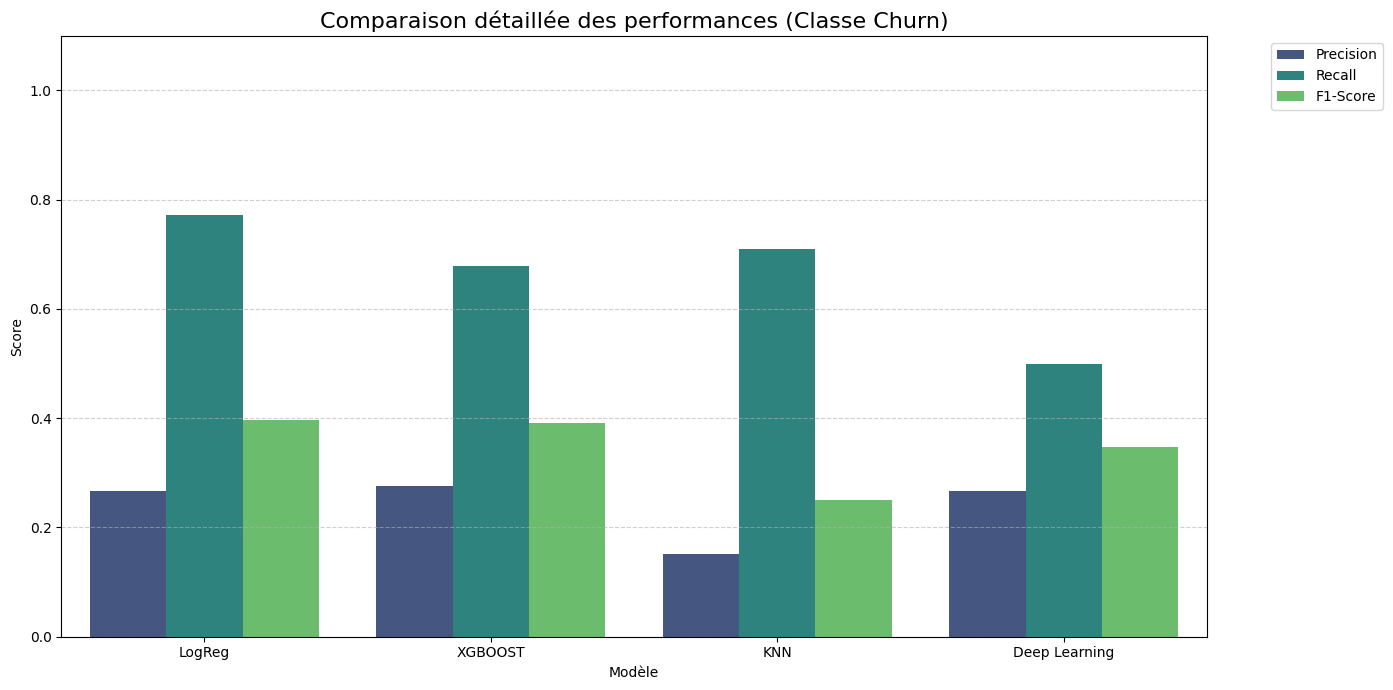

In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# 1. Préparation des rapports (Inchangé)
reports = {
    'LogReg': classification_report(y_test, y_pred_logreg, output_dict=True),
    'XGBOOST': classification_report(y_test, y_pred_xgb, output_dict=True),
    'KNN': classification_report(y_test, y_pred_knn_smote, output_dict=True),
    'Deep Learning': classification_report(y_test_np, y_pred_np, output_dict=True)
}

# 2. Extraction avec RÈGLE SPÉCIALE pour gérer '1' ou '1.0'
data = []
for model_name, report in reports.items():
    # Règle spéciale : on cherche '1', si absent on cherche '1.0', si absent on met des zéros
    stats = report.get('1', report.get('1.0', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0}))
    
    data.append({
        'Modèle': model_name,
        'Precision': stats['precision'],
        'Recall': stats['recall'],
        'F1-Score': stats['f1-score']
    })

# 3. Création du DataFrame et transformation pour Seaborn (format long)
df_results = pd.DataFrame(data).melt(id_vars='Modèle', var_name='Métrique', value_name='Score')

# 4. Graphique
plt.figure(figsize=(14, 7))
sns.barplot(data=df_results, x='Modèle', y='Score', hue='Métrique', palette='viridis')

plt.title('Comparaison détaillée des performances (Classe Churn)', fontsize=16)
plt.ylim(0, 1.1) 
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Sauvgarde du meilleur modele et du préprocesseur

In [114]:
import joblib

# 1. On sauvegarde (on écrase) l'ancien modèle avec le nouveau modèle optimisé
joblib.dump(xgb_model, 'models/logreg.pkl')
print(" Modèle LogReg optimisé sauvegardé sous 'models/logreg.pkl'")

# Sauvegarde de ton pipeline de préparation des données (Le Traducteur)
joblib.dump(preprocessor, 'models/preprocessor.pkl')

print("Preprocessor sauvegardé avec succès sous le nom 'preprocessor.pkl' !")

 Modèle LogReg optimisé sauvegardé sous 'models/logreg.pkl'
Preprocessor sauvegardé avec succès sous le nom 'preprocessor.pkl' !


# Modélisation et Choix du Modèle Final

### 1. Méthodologie de sélection des variables
* **Approche par élimination :** Nous avons d'abord entraîné un modèle repère avec toutes les données disponibles. Ensuite, nous avons testé une version allégée en supprimant les colonnes identifiées comme du "bruit" statistique lors de notre nettoyage (tests de Chi² et Corrélation).
* **Validation :** En comparant les deux approches, les scores de prédiction sont restés identiques. Cela confirme que ces colonnes n'apportaient aucune information utile. Nous avons donc conservé le modèle allégé : un algorithme plus simple est plus rapide, plus robuste et moins sujet aux interférences.

### 2. Algorithmes mis en compétition
Afin d'identifier le meilleur moteur de prédiction pour notre problématique, nous avons mis en compétition quatre approches :

* **Régression Logistique :** Notre modèle de référence. Simple et transparent, il calcule mathématiquement la probabilité d'appartenance à une classe (rester ou partir).
* **XGBoost :** Méthode d'ensemble par *gradient boosting* extrêmement performante pour les données tabulaires. 

* **KNN (K-Plus Proches Voisins) :** Méthode basée sur la "distance" ou la similarité. L'algorithme identifie les *K* clients les plus proches du profil cible pour déduire son futur comportement.
* **Deep Learning (PyTorch) :** Architecture de réseaux de neurones multicouches (MLP) entraînée pour capturer des relations non-linéaires complexes.


[Image of neural network architecture for classification]


### 3. Métriques d'évaluation
Dans notre contexte de prédiction de résiliation (*Churn*), les métriques ne se valent pas toutes :

* **Accuracy :** Pourcentage de réponses correctes sur l'ensemble du dataset. Attention : très trompeuse en cas de classes déséquilibrées.
* **Recall (Rappel) :** Notre métrique reine. Parmi tous les clients qui ont *réellement* résilié, combien notre modèle a-t-il réussi à détecter ?
* **Precision :** Parmi tous les clients pointés du doigt comme "allant résilier", combien le font réellement ?
* **F1-Score :** Le compromis (moyenne harmonique) entre Precision et Recall. C'est la métrique la plus robuste pour juger la capacité du modèle à traiter la classe minoritaire.

### 4. Synthèse et choix du modèle
Après évaluation, **la Régression Logistique a été retenue comme modèle final.**

| Modèle | Précision (Churn) | Rappel (Churn) | F1-Score |
| :--- | :--- | :--- | :--- |
| **Régression Logistique** | **0.27** | **0.77** | **0.40** |
| KNN | 0.15 | 0.71 | 0.25 |
| XGBoost | 0.28 | 0.68 | 0.39 |
| Deep Learning | 0.26 | 0.42 | 0.32 |

**Justification :** Bien que des modèles comme le XGBoost soient très performants, la Régression Logistique offre le meilleur compromis métier. Son **Rappel de 0.77** est le plus élevé, garantissant que nous ne laissons pas passer les clients à risque, tout en offrant une **interprétabilité totale** des coefficients, un atout majeur pour les actions marketing.


# Analyse Business et Impact


## 2. Impact Métier
Le déploiement de ce modèle de Machine Learning va transformer concrètement la réalité opérationnelle de l'entreprise :

- **Passage d'une posture réactive à proactive :** L'entreprise ne subira plus les résiliations avec fatalité. Elle aura les cartes en main pour anticiper et retenir le client *avant* qu'il ne clique sur le bouton de désabonnement.
- **Optimisation financière (ROI) :** Acquérir un nouveau client coûte nettement plus cher que d'en retenir un existant. En ciblant chirurgicalement les efforts promotionnels sur les clients *réellement* à risque (plutôt que d'offrir des remises à tout le monde), l'entreprise optimise son budget marketing.
- **Protection du chiffre d'affaires récurrent :** En repérant à l'avance les clients à forte valeur ajoutée qui menacent de partir à cause d'une baisse de satisfaction, nous sécurisons les fondations financières de l'entreprise.


## 3. Limites du projet
Malgré la robustesse de notre modèle, cette analyse présente quelques limites qu'il est important de souligner :

- **Une photographie figée :** Notre dataset représente les données à un instant T. Les comportements des clients évoluent vite, et un modèle non mis à jour perdra rapidement en précision.
- **Manque de données qualitatives :** Si l'algorithme identifie qu'un client n'est pas satisfait (CSAT faible), il ne nous dit pas *pourquoi*. L'absence des textes exacts des réclamations ou des notes d'appels du support technique nous prive d'un contexte précieux.
- **Corrélation vs Causalité :** Le modèle propose des probabilités de départ, mais ne garantit pas que la solution marketing envisagée fonctionnera sur chaque individu. L'humain reste imprévisible.


## 4. Perspectives et Prochaines Étapes

- **Enrichissement des données (Data Lake) :** Croiser notre dataset actuel avec d'autres bases de données internes (par exemple, l'analyse NLP des tickets Zendesk ou des e-mails du service client) permettrait de nourrir le modèle avec des émotions et des mots-clés, augmentant encore sa précision.
- **Automatisation (MLOps) :** Mettre en place un pipeline automatisé qui réentraîne l'algorithme tous les mois avec les nouvelles données récoltées. Cela garantit que le modèle s'adapte en continu aux nouvelles tendances de résiliation.

## Sauvagarde des transformations dans un csv silver

In [115]:
df_silver = df_cleaned.drop_duplicates()
df_silver.to_csv("data/silver_customer_churn_business_dataset.csv")